In [1]:
### Hayden Gallo
### 9/29/25
### Bucci Lab
### Running gLV-FBA on Venturelli data


import numpy as np
#from dfba import DfbaModel, ExchangeFlux, KineticVariable
import cobra
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import math
#from numba import njit
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares
from scipy.optimize import curve_fit
import sys
import os
import openpyxl
import gurobipy

import pymc as pm
import pytensor
import pytensor.tensor as pt
from pymc.ode import DifferentialEquation
from pytensor.compile.ops import as_op
import arviz as az

import time
import joblib
import multiprocessing
from scipy.stats import truncnorm
import copy
from pathlib import Path
import subprocess

### script for running glv_dfba inference
import argparse
import re

from helper_functions import *

from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages
import json
import logging
from scipy.stats import pearsonr, spearmanr

WARNING (pytensor.configdefaults): Only clang++ is supported. With g++, we end up with strange g++/OSX bugs.


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
! export GRB_LICENSE_FILE=/Users/haydengallo/.gurobi/gurobi.lic

In [4]:
#################################################################################################################################################################
### this is used to surpress all logging from loading in the kbase models with cobra, such that they don't get added to the glv_fba log file and overcrowd it ### 
logging.getLogger("cobra").setLevel(logging.ERROR)
#################################################################################################################################################################

In [5]:
### define generalized Lotka-Volterra function 
def gLV(t, init_abun, paired_growth_matrix, basal_grow):

    return ((np.dot(init_abun, paired_growth_matrix) + basal_grow) * init_abun)

In [6]:
### Setting up some metadata from metadata_2019_06_17.py Clark et al 2021 


#Define the descriptors involved in this experiment
numspecies=25
allspecies=['ER','FP','AC','CC','RI','EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA']
phylogeny=['PC','PJ','BV','BF','BO','BT','BC','BY','BU','DP','BL','BA','BP','CA','EL','FP','CH','AC','BH','CG','ER','RI','CC','DL','DF']
phylogeny_nobpb=['PC','PJ','BV','BF','BO','BT','BC','BY','BU','DP','BL','BA','BP','CA','EL','CH','BH','CG','DL','DF']
phylogeny_nogaps=['PC','PJ','BF','BO','BT','DP','BA','BP','CA','EL','CH','BH','CG','DL','DF']
speciesvectorDict={}
n=1
for species in allspecies:
	speciesvectorDict[species]=n
	n+=1

k=0
phylogenyvectorDict={}
for species in phylogeny:
	phylogenyvectorDict[species]=k
	k+=1

bpbindices=[15,17,20,21,22]
bpbspecies=['ER','FP','AC','CC','RI']
spbspecies=['PJ','BT','BF','BC','BO','BV','PC']
others=['EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA']
comms=['COMM0','COMM1','COMM2','COMM3','COMM4']

commsDict={
	'COMM0':['DP','BH','CA','PC','EL','CH','BO','BT','BU','BV'],
	'COMM1':['ER','FP','DP','BH','CA','PC','EL','CH','BO','BT','BU','BV'],
	'COMM2':['ER','FP','AC','HB','CC','RI','DP','BH','CA','PC','EL','CH','BO','BT','BU','BV'],
	'COMM3':['ER','FP','AC','HB','CC','RI','EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA'],
	'COMM4':['EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA'],
	'COMM5':['ER','FP','AC','CC','RI','DP','BH','CA','PC','EL','CH','BO','BT','BU','BV'],
	'COMM6':['ER','FP','AC','CC','RI','EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA'],
	'COMM7':['ER','FP','RI','BH','DP','PJ','AC','CC','BV','DL','BY','BL','DF','BA','EL'],
	'COMM8':['ER','FP','RI','AC','CC']
}

COMM0=['DP','BH','CA','PC','EL','CH','BO','BT','BU','BV']
COMM1=['ER','FP','DP','BH','CA','PC','EL','CH','BO','BT','BU','BV']
COMM2=['ER','FP','AC','HB','CC','RI','DP','BH','CA','PC','EL','CH','BO','BT','BU','BV']
COMM3=['ER','FP','AC','HB','CC','RI','EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA']
COMM4=['EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA']
COMM5=['ER','FP','AC','CC','RI','DP','BH','CA','PC','EL','CH','BO','BT','BU','BV']
COMM6=['ER','FP','AC','CC','RI','EL','CH','DP','BH','CA','PC','PJ','DL','CG','BF','BO','BT','BU','BV','BC','BY','DF','BL','BP','BA']
COMM7=['ER','FP','RI','BH','DP','PJ','AC','CC','BV','DL','BY','BL','DF','BA','EL']
COMM8=['ER','FP','RI','AC','CC']

LOOComms=['COMM6']
for species in phylogeny:
	LOOComms.append('COMM6*'+species)

		
namedict={
   'BA': 'Bifidobacterium_adolescentis_ATCC_15703_NC_008618',
   'CA': 'Collinsella_aerofaciens_ATCC_25986',
   'BT': 'Bacteroides_thetaiotaomicron_VPI-5482_NC_004663',
   'BU': 'Bacteroides_uniformis_ATCC_8492',
   'PC': 'Prevotella_copri_DSM_18205',
   'AC': 'Anaerostipes_caccae_DSM_14662_4',
   'BH': 'Blautia_hydrogenotrophica_DSM_10507',
   'CC': 'Coprococcus_comes_1.0.1_Cont2276_NZ_ABVR01000038',
   'CG': 'Clostridium_asparagiforme_DSM_15981_C_asparagiforme_1.0_Cont7.2_NZ_ACCJ01000522',
   'ER': 'Eubacterium_rectale_ATCC_33656_NC_012781',
   'DP': 'Desulfovibrio_piger_ATCC_29098',
   'EL': 'Eggerthella_lenta_DSM_2243_NC_013204',
   'BY': 'Bacteroides_cellulosilyticus_DSM_14838_1.0_Cont4.1_NZ_ACCH01000108',
   'BF': 'Bacteroides_fragilis_NCTC_9343',
   'CD': 'Clostridioides_difficile',
   'RI': 'Roseburia_intestinalis_L1_82',
   'BP': 'Bifidobacterium_pseudocatenulatum_DSM20438',
   'BV': 'Bacteroides_vulgatus_ATCC_8482_NC_009614',
   'CH': 'Clostridium_hiranonis_DSM_13275',
   'DF': 'Dorea_formicigenerans_ATCC_27755',
   'CS': 'Clostridium_scindens_ATCC_35704',
   'PJ': 'Parabacteroides_johnsonii_DSM_18315_NZ_ABYH01000014',
   'FP': 'Faecalibacterium_prausnitzii_A2_165_NZ',
   'EH': 'Eubacterium_hallii_DSM_3353_1.0_Cont383.1_NZ_ACEP01000116',
   'EC': 'Escherichia_coli',
   'BC': 'Bacteroides_caccae_ATCC_43185',
   'HB': 'Holdemanella_biformis_DSM_3989',
   'BO': 'Bacteroides_ovatus_ATCC_8483',
   'DL': 'Dorea_longicatena_DSM_13814',
   'BL': 'Bifidobacterium_longum_subsp_infantis',
   'B.cereus':'Bacillus_cereus'
   }


In [14]:
data_dir = '/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_data'

#data_dir = '/Users/haydengallo/UMass_Dropbox/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_data'

In [17]:
## load in the data needed for running simulations

### this is int matrix from MDSINE2
int_matrix = np.load('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_long_MDSINE_fit/merged_studies_test_3/int_matrix.npy', allow_pickle=True)
### this is int matrix from Venturelli 
#int_matrix_path = data_dir + '/interaction_matrix.npy'
#int_matrix = np.load(int_matrix_path, allow_pickle=True)

### this is growth rates from MDSINE2
growth_rates = np.load('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_long_MDSINE_fit/merged_studies_test_3/growth_rates.npy', allow_pickle=True)
### this is growth rates from Venturelli 
#growth_rates_path = data_dir + '/growth_rates.npy'
#growth_rates = np.load(growth_rates_path, allow_pickle=True)

m2_init_abun_path = data_dir + '/m2_time_series_init_no_mets.csv'
m2_init_abun = pd.read_csv(m2_init_abun_path)

m2_init_abun = m2_init_abun.set_index('Experiments')


m2_final_abun_path = data_dir + '/m2_time_series_final_w_mets.csv'
m2_final_abun = pd.read_csv(m2_final_abun_path, index_col = 0)

m2_final_abun = m2_final_abun.set_index('Experiments')

m2_final_abun

,Time,ER_OD,FP_OD,AC_OD,CC_OD,RI_OD,DP_OD,BH_OD,CA_OD,PC_OD,...,BY_OD,PJ_OD,DF_OD,BL_OD,BP_OD,BA_OD,Butyrate,Acetate,Lactate,Succinate
Experiments,,,,,,,,,,,,,,,,,,,,,
AC,48.0,0.000000,0.000000,1.020936,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,31.478250,4.609550,19.788250,3.857050
AC_BA,48.0,0.000000,0.000000,0.534301,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.844040,46.569600,16.771500,10.611000,5.175300
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_DP_EL_ER_FP_PC_PJ_RI,48.0,0.019701,0.000141,0.595550,0.045924,0.000000,0.002039,0.000070,0.001149,0.000000,...,0.068783,0.025191,0.036298,0.003725,0.202176,0.065080,16.747969,43.975915,40.116033,14.561263
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_EL_ER_FP_PC_PJ_RI,48.0,0.013610,0.000584,0.619676,0.059597,0.000476,0.000000,0.000363,0.049423,0.000000,...,0.074525,0.023666,0.050836,0.003792,0.175482,0.104346,32.083082,36.775846,19.185251,17.346756
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_DP_EL_ER_FP_PC_PJ_RI,48.0,0.082073,0.000726,0.621015,0.094951,0.000363,0.002640,0.000498,0.014217,0.008162,...,0.041856,0.034299,0.061095,0.016494,0.345622,0.232925,18.190000,40.175000,49.500000,7.710000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC,48.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.757768,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.736800,19.864200,46.006000
PC_RI,48.0,0.000000,0.000000,0.000000,0.000000,0.483542,0.000000,0.000000,0.000000,1.124425,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,15.442400,17.364100,22.486900,40.750100
PJ,48.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.882363,0.000000,0.000000,0.000000,0.000000,0.000000,17.319400,23.916900,23.650300


In [26]:
### load in mutlifunctional dataset

multi_func_data = pd.read_csv('/Users/haydengallo/UMass Medical School Dropbox/Hayden Gallo/Bucci_Lab/glv_FBA/Venturelli_data/Baranwal_et_al_2022/2021_02_19_MultifunctionalDynamicData.csv', index_col = 0)
multi_func_data.head()

,Community,Time,Richness,Contamination,PC,PC_OD,PJ,PJ_OD,BV,BV_OD,...,CC_OD,DL,DL_OD,DF,DF_OD,OD,Butyrate,Acetate,Lactate,Succinate
0,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.0,14.0,No,1.0,0.000471,0.0,0.0,1.0,0.000471,...,0.0,0.0,0.0,1.0,0.000471,0.006600,0.000000,0.000000,28.000000,0.000000
1,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,16.0,14.0,No,1.0,0.465116,0.0,0.0,1.0,0.029207,...,0.0,0.0,0.0,1.0,0.392830,2.454333,23.092697,47.849302,18.910852,26.141885
2,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,32.0,14.0,No,1.0,0.104523,0.0,0.0,1.0,0.027928,...,0.0,0.0,0.0,1.0,0.280111,2.180333,23.996267,38.915218,17.977137,26.884748
3,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,48.0,14.0,No,1.0,0.124852,0.0,0.0,1.0,0.012194,...,0.0,0.0,0.0,1.0,0.224952,1.972333,24.839219,34.325914,19.406971,31.628060
4,BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-E...,0.0,17.0,No,0.0,0.000000,0.0,0.0,1.0,0.000388,...,0.0,0.0,0.0,0.0,0.000000,0.006600,0.000000,0.000000,28.000000,0.000000


In [51]:
multi_func_data_filt = multi_func_data.filter(regex = '_OD|Community|Time|Butyrate|Succinate|Acetate|Lactate', axis =1)
multi_func_data_filt.columns = list(multi_func_data_filt.columns.str.split('_').str[0])
multi_func_data_filt = multi_func_data_filt.rename(columns={'Community':'Experiments'})
multi_func_data_filt

,Experiments,Time,PC,PJ,BV,BF,BO,BT,BC,BY,...,CG,ER,RI,CC,DL,DF,Butyrate,Acetate,Lactate,Succinate
0,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.0,0.000471,0.000000,0.000471,0.000000,0.000000,0.000471,0.000471,0.000000,...,0.000471,0.000471,0.000471,0.000000,0.000000,0.000471,0.000000,0.000000,28.000000,0.000000
1,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,16.0,0.465116,0.000000,0.029207,0.000000,0.000000,0.249717,0.500651,0.000000,...,0.024339,0.327601,0.001460,0.000000,0.000000,0.392830,23.092697,47.849302,18.910852,26.141885
2,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,32.0,0.104523,0.000000,0.027928,0.000000,0.000000,0.220107,0.380210,0.000000,...,0.020739,0.293384,0.000830,0.000000,0.000000,0.280111,23.996267,38.915218,17.977137,26.884748
3,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,48.0,0.124852,0.000000,0.012194,0.000000,0.000000,0.268268,0.333970,0.000000,...,0.023660,0.188188,0.002366,0.000000,0.000000,0.224952,24.839219,34.325914,19.406971,31.628060
4,BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-E...,0.0,0.000000,0.000000,0.000388,0.000388,0.000388,0.000388,0.000000,0.000000,...,0.000388,0.000388,0.000388,0.000000,0.000000,0.000000,0.000000,0.000000,28.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,PJ-BV-BO-BU-CA-EL-FP-CH-BH-CG-ER,48.0,0.000000,0.028274,0.028875,0.000000,0.774516,0.000000,0.000000,0.000000,...,0.064067,0.247995,0.000000,0.000000,0.000000,0.000000,8.062090,46.538322,28.721049,38.398845
376,PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-F...,0.0,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,...,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000000,0.000000,28.000000,0.000000
377,PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-F...,16.0,0.079924,0.006808,0.038778,0.136315,0.135575,0.152595,0.251168,0.077704,...,0.013321,0.185009,0.000888,0.003848,0.218459,0.117074,20.398944,44.685687,29.860716,16.868235
378,PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-F...,32.0,0.102594,0.005985,0.007552,0.103306,0.094044,0.099174,0.175977,0.061271,...,0.012539,0.134654,0.000285,0.006127,0.225279,0.130522,21.118467,40.780611,31.049107,19.133824


In [45]:
multi_func_data_filt

,Experiments,Time,PC,PJ,BV,BF,BO,BT,BC,BY,...,FP,CH,AC,BH,CG,ER,RI,CC,DL,DF
0,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.0,0.000471,0.000000,0.000471,0.000000,0.000000,0.000471,0.000471,0.000000,...,0.000471,0.000471,0.000471,0.000471,0.000471,0.000471,0.000471,0.000000,0.000000,0.000471
1,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,16.0,0.465116,0.000000,0.029207,0.000000,0.000000,0.249717,0.500651,0.000000,...,0.001217,0.061091,0.351454,0.000974,0.024339,0.327601,0.001460,0.000000,0.000000,0.392830
2,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,32.0,0.104523,0.000000,0.027928,0.000000,0.000000,0.220107,0.380210,0.000000,...,0.000830,0.121667,0.700970,0.001106,0.020739,0.293384,0.000830,0.000000,0.000000,0.280111
3,PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,48.0,0.124852,0.000000,0.012194,0.000000,0.000000,0.268268,0.333970,0.000000,...,0.001092,0.170898,0.605696,0.000546,0.023660,0.188188,0.002366,0.000000,0.000000,0.224952
4,BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-E...,0.0,0.000000,0.000000,0.000388,0.000388,0.000388,0.000388,0.000000,0.000000,...,0.000388,0.000388,0.000388,0.000388,0.000388,0.000388,0.000388,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
375,PJ-BV-BO-BU-CA-EL-FP-CH-BH-CG-ER,48.0,0.000000,0.028274,0.028875,0.000000,0.774516,0.000000,0.000000,0.000000,...,0.000301,0.396131,0.000000,0.001354,0.064067,0.247995,0.000000,0.000000,0.000000,0.000000
376,PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-F...,0.0,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,...,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264
377,PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-F...,16.0,0.079924,0.006808,0.038778,0.136315,0.135575,0.152595,0.251168,0.077704,...,0.000000,0.025605,0.039962,0.000148,0.013321,0.185009,0.000888,0.003848,0.218459,0.117074
378,PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-F...,32.0,0.102594,0.005985,0.007552,0.103306,0.094044,0.099174,0.175977,0.061271,...,0.000142,0.029068,0.234826,0.000285,0.012539,0.134654,0.000285,0.006127,0.225279,0.130522


In [55]:
multi_func_data_filt_reorder = multi_func_data_filt.set_index('Experiments')
multi_func_data_filt_reorder = multi_func_data_filt_reorder.drop(['Time','Butyrate','Succinate','Acetate','Lactate'], axis=1)[m2_init_abun.columns.to_list()]
multi_func_data_filt_reorder['Time'] = multi_func_data_filt['Time'].to_list()
multi_func_data_filt_reorder['Butyrate'] = multi_func_data_filt['Butyrate'].to_list()
multi_func_data_filt_reorder['Succinate'] = multi_func_data_filt['Succinate'].to_list()
multi_func_data_filt_reorder['Acetate'] = multi_func_data_filt['Acetate'].to_list()
multi_func_data_filt_reorder['Lactate'] = multi_func_data_filt['Lactate'].to_list()
multi_func_data_filt_reorder

,ER,FP,AC,CC,RI,EL,CH,DP,BH,CA,...,BY,DF,BL,BP,BA,Time,Butyrate,Succinate,Acetate,Lactate
Experiments,,,,,,,,,,,,,,,,,,,,,
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.000471,0.000471,0.000471,0.000000,0.000471,0.000471,0.000471,0.000000,0.000471,0.000000,...,0.000000,0.000471,0.000000,0.000471,0.000000,0.0,0.000000,0.000000,0.000000,28.000000
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.327601,0.001217,0.351454,0.000000,0.001460,0.000974,0.061091,0.000000,0.000974,0.000000,...,0.000000,0.392830,0.000000,0.042593,0.000000,16.0,23.092697,26.141885,47.849302,18.910852
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.293384,0.000830,0.700970,0.000000,0.000830,0.002765,0.121667,0.000000,0.001106,0.000000,...,0.000000,0.280111,0.000000,0.025163,0.000000,32.0,23.996267,26.884748,38.915218,17.977137
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.188188,0.001092,0.605696,0.000000,0.002366,0.001638,0.170898,0.000000,0.000546,0.000000,...,0.000000,0.224952,0.000000,0.013650,0.000000,48.0,24.839219,31.628060,34.325914,19.406971
BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-ER-RI,0.000388,0.000388,0.000388,0.000000,0.000388,0.000388,0.000388,0.000388,0.000388,0.000000,...,0.000000,0.000000,0.000388,0.000388,0.000388,0.0,0.000000,0.000000,0.000000,28.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PJ-BV-BO-BU-CA-EL-FP-CH-BH-CG-ER,0.247995,0.000301,0.000000,0.000000,0.000000,0.001955,0.396131,0.000000,0.001354,0.022258,...,0.000000,0.000000,0.000000,0.000000,0.000000,48.0,8.062090,38.398845,46.538322,28.721049
PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-FP-CH-AC-BH-CG-ER-RI-CC-DL-DF,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,...,0.000264,0.000264,0.000264,0.000264,0.000264,0.0,0.000000,0.000000,0.000000,28.000000
PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-FP-CH-AC-BH-CG-ER-RI-CC-DL-DF,0.185009,0.000000,0.039962,0.003848,0.000888,0.000888,0.025605,0.004292,0.000148,0.007992,...,0.077704,0.117074,0.005032,0.056095,0.078444,16.0,20.398944,16.868235,44.685687,29.860716


In [59]:
multi_func_data_filt_reorder_initial = multi_func_data_filt_reorder[multi_func_data_filt_reorder['Time'] == 0.0].drop(['Time','Butyrate','Succinate','Acetate','Lactate'], axis=1)
multi_func_data_filt_reorder_initial

,ER,FP,AC,CC,RI,EL,CH,DP,BH,CA,...,BO,BT,BU,BV,BC,BY,DF,BL,BP,BA
Experiments,,,,,,,,,,,,,,,,,,,,,
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.000471,0.000471,0.000471,0.000000,0.000471,0.000471,0.000471,0.000000,0.000471,0.000000,...,0.000000,0.000471,0.000000,0.000471,0.000471,0.000000,0.000471,0.000000,0.000471,0.000000
BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-ER-RI,0.000388,0.000388,0.000388,0.000000,0.000388,0.000388,0.000388,0.000388,0.000388,0.000000,...,0.000388,0.000388,0.000388,0.000388,0.000000,0.000000,0.000000,0.000388,0.000388,0.000388
PJ-BO-BT-BC-BY-BA-CA-EL-FP-CH-AC-BH-CG-CC-DF,0.000000,0.000440,0.000440,0.000440,0.000000,0.000440,0.000440,0.000000,0.000440,0.000440,...,0.000440,0.000440,0.000000,0.000000,0.000440,0.000440,0.000440,0.000000,0.000000,0.000440
PC-PJ-BF-BO-BU-DP-BA-EL-CH-BH-CG,0.000000,0.000000,0.000000,0.000000,0.000000,0.000600,0.000600,0.000600,0.000600,0.000000,...,0.000600,0.000000,0.000600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000600
PC-PJ-BV-BF-BT-BL-CA-EL-FP-CH-BH-CC-DF,0.000000,0.000508,0.000000,0.000508,0.000000,0.000508,0.000508,0.000000,0.000508,0.000508,...,0.000000,0.000508,0.000000,0.000508,0.000000,0.000000,0.000508,0.000508,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC-PJ-BF-BO-BU-DP-BA-CA-EL-FP-CH-AC-BH-ER-CC-DL-DF,0.000388,0.000388,0.000388,0.000388,0.000000,0.000388,0.000388,0.000388,0.000388,0.000388,...,0.000388,0.000000,0.000388,0.000000,0.000000,0.000000,0.000388,0.000000,0.000000,0.000388
PC-BV-BF-BO-BT-BU-DP-CA-EL-FP-BH-CG-DF,0.000000,0.000508,0.000000,0.000000,0.000000,0.000508,0.000000,0.000508,0.000508,0.000508,...,0.000508,0.000508,0.000508,0.000508,0.000000,0.000000,0.000508,0.000000,0.000000,0.000000
PJ-BF-BO-BT-BC-BY-BU-DP-BL-BA-CH-AC-CG-RI-CC-DF,0.000000,0.000000,0.000412,0.000412,0.000412,0.000000,0.000412,0.000412,0.000000,0.000000,...,0.000412,0.000412,0.000412,0.000000,0.000412,0.000412,0.000412,0.000412,0.000000,0.000412


In [58]:
multi_func_data_filt_reorder_final = multi_func_data_filt_reorder[multi_func_data_filt_reorder['Time'] != 0.0]
multi_func_data_filt_reorder_final

,ER,FP,AC,CC,RI,EL,CH,DP,BH,CA,...,BY,DF,BL,BP,BA,Time,Butyrate,Succinate,Acetate,Lactate
Experiments,,,,,,,,,,,,,,,,,,,,,
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.327601,0.001217,0.351454,0.000000,0.001460,0.000974,0.061091,0.000000,0.000974,0.000000,...,0.000000,0.392830,0.000000,0.042593,0.000000,16.0,23.092697,26.141885,47.849302,18.910852
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.293384,0.000830,0.700970,0.000000,0.000830,0.002765,0.121667,0.000000,0.001106,0.000000,...,0.000000,0.280111,0.000000,0.025163,0.000000,32.0,23.996267,26.884748,38.915218,17.977137
PC-BV-BT-BC-BP-EL-FP-CH-AC-BH-CG-ER-RI-DF,0.188188,0.001092,0.605696,0.000000,0.002366,0.001638,0.170898,0.000000,0.000546,0.000000,...,0.000000,0.224952,0.000000,0.013650,0.000000,48.0,24.839219,31.628060,34.325914,19.406971
BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-ER-RI,0.341142,0.000291,0.071513,0.000000,0.001454,0.002762,0.078054,0.004506,0.000436,0.000000,...,0.000000,0.000000,0.016279,0.203784,0.189249,16.0,15.428777,13.716029,48.666379,38.993601
BV-BF-BO-BT-BU-DP-BL-BA-BP-EL-FP-CH-AC-BH-CG-ER-RI,0.229383,0.000863,0.270635,0.000000,0.001726,0.003625,0.106148,0.005005,0.000173,0.000000,...,0.000000,0.000000,0.016397,0.206600,0.104077,32.0,15.866748,13.200052,48.024758,42.643855
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PJ-BV-BO-BU-CA-EL-FP-CH-BH-CG-ER,0.258735,0.001518,0.000000,0.000000,0.000000,0.000911,0.415039,0.000000,0.002276,0.019272,...,0.000000,0.000000,0.000000,0.000000,0.000000,32.0,7.874690,33.319109,48.008226,26.577511
PJ-BV-BO-BU-CA-EL-FP-CH-BH-CG-ER,0.247995,0.000301,0.000000,0.000000,0.000000,0.001955,0.396131,0.000000,0.001354,0.022258,...,0.000000,0.000000,0.000000,0.000000,0.000000,48.0,8.062090,38.398845,46.538322,28.721049
PC-PJ-BV-BF-BO-BT-BC-BY-BU-DP-BL-BA-BP-CA-EL-FP-CH-AC-BH-CG-ER-RI-CC-DL-DF,0.185009,0.000000,0.039962,0.003848,0.000888,0.000888,0.025605,0.004292,0.000148,0.007992,...,0.077704,0.117074,0.005032,0.056095,0.078444,16.0,20.398944,16.868235,44.685687,29.860716


In [21]:
growth_rates

array([0.08525604, 0.00204951, 0.17341124, 0.02717554, 0.00642041,
       0.01998709, 0.0064167 , 0.11574334, 0.1409729 , 0.12003911,
       0.05250729, 0.12068758, 0.01705934, 0.0744326 , 0.14048568,
       0.14563285, 0.14783396, 0.14417452, 0.12626738, 0.12523616,
       0.09500985, 0.17986866, 0.01570223, 0.06044466, 0.08607149])

In [22]:
m2_final_abun = m2_final_abun.drop(columns = ['Time'])
m2_final_abun_met  = m2_final_abun[['Butyrate', 'Acetate', 'Lactate', 'Succinate']]
m2_final_abun_bac = m2_final_abun.drop(columns = ['Butyrate', 'Acetate', 'Lactate', 'Succinate'])

In [23]:
time = np.linspace(0,48,49)
args = (int_matrix, growth_rates)

In [24]:
### Sanity check to make sure things are good to start simulating 


final_prediction = np.zeros([len(m2_init_abun), 25])

for i in range(0, len(m2_init_abun)):

    init_abun = np.array(m2_init_abun.iloc[i,:].to_list())
    sol = odeint(gLV,  init_abun,time, args = args, tfirst = True)
    final_prediction[i,:] = sol[-1,:]

final_prediction


array([[0.00000000e+00, 0.00000000e+00, 2.71956637e+01, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.35978773e+01, ...,
        0.00000000e+00, 0.00000000e+00, 2.05481104e-01],
       [1.58075590e-02, 2.91291804e-04, 1.08790728e+00, ...,
        5.60963589e-04, 4.80443100e-03, 1.64385624e-02],
       ...,
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, ...,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00]])

In [12]:
#list(cobra_models.keys())

count = 0

for i in range(0, len(m2_init_abun)):

    index = list(m2_init_abun.index)[i]
    if index == 'CA':
        print(count)
    count +=1

m2_init_abun.loc['CA']

663


ER_OD    0.0000
FP_OD    0.0000
AC_OD    0.0000
CC_OD    0.0000
RI_OD    0.0000
DP_OD    0.0000
BH_OD    0.0000
CA_OD    0.0066
PC_OD    0.0000
DL_OD    0.0000
CG_OD    0.0000
BF_OD    0.0000
EL_OD    0.0000
CH_OD    0.0000
BO_OD    0.0000
BT_OD    0.0000
BU_OD    0.0000
BV_OD    0.0000
BC_OD    0.0000
BY_OD    0.0000
PJ_OD    0.0000
DF_OD    0.0000
BL_OD    0.0000
BP_OD    0.0000
BA_OD    0.0000
Name: CA, dtype: float64

In [13]:
m2_init_abun

,ER_OD,FP_OD,AC_OD,CC_OD,RI_OD,DP_OD,BH_OD,CA_OD,PC_OD,DL_OD,...,BT_OD,BU_OD,BV_OD,BC_OD,BY_OD,PJ_OD,DF_OD,BL_OD,BP_OD,BA_OD
Experiments,,,,,,,,,,,,,,,,,,,,,
AC,0.000000,0.000000,0.006600,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
AC_BA,0.000000,0.000000,0.003300,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003300
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,...,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_EL_ER_FP_PC_PJ_RI,0.000275,0.000275,0.000275,0.000275,0.000275,0.000000,0.000275,0.000275,0.000275,0.000275,...,0.000275,0.000275,0.000275,0.000275,0.000275,0.000275,0.000275,0.000275,0.000275,0.000275
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,...,0.000000,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287,0.000287
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PC,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.006600,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PC_RI,0.000000,0.000000,0.000000,0.000000,0.003300,0.000000,0.000000,0.000000,0.003300,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
PJ,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.006600,0.000000,0.000000,0.000000,0.000000


In [14]:
### load in all of the GEMs

### load the cobra models into memory i guess

#cobra_models_dir_path = data_dir + '/AGORA_GEMs'
cobra_models_dir_path = data_dir + '/panGenusModels_Venturelli'

cobra_models_dir = Path(cobra_models_dir_path)

# Make the data and validation Study objects
cobra_models = sorted(cobra_models_dir.glob('*.mat'))
cobra_models = {f.stem : f for f in cobra_models}

### Just loading the models needed in 

loaded_models = {}

#count = 0

for key in cobra_models:
    #if count == 1:
    #    break
    #print(key.split('_'))
    #model_name = key.split('_')[0] + '_' + key.split('_')[1]
    model_name = key.split('.')[0]
    model_name = model_name[3:]
    #print(model_name)
    model = cobra.io.load_matlab_model(cobra_models[key])
    loaded_models[model_name] = model
    #count+=1



Restricted license - for non-production use only - expires 2025-11-24


In [15]:
#loaded_models['Anaerostipes_caccae'].slim_optimize()

In [16]:
loaded_models

{'Anaerostipes': <Model model at 0x35d8c76b0>,
 'Bacteroides': <Model model at 0x35f607c50>,
 'Bifidobacterium': <Model model at 0x35ee4c230>,
 'Blautia': <Model model at 0x35d567350>,
 'Clostridium': <Model model at 0x37c83c2f0>,
 'Collinsella': <Model model at 0x37af12ab0>,
 'Coprococcus': <Model model at 0x35d8acfe0>,
 'Desulfovibrio': <Model model at 0x35d668da0>,
 'Dorea': <Model model at 0x37ae53920>,
 'Eggerthella': <Model model at 0x35f6c85c0>,
 'Eubacterium': <Model model at 0x3a13818e0>,
 'Faecalibacterium': <Model model at 0x3a25160c0>,
 'Parabacteroides': <Model model at 0x3a3b38ec0>,
 'Prevotella': <Model model at 0x3a39e0740>,
 'Roseburia': <Model model at 0x3a3900140>}

In [17]:
loaded_models['Anaerostipes'].reactions

[<Reaction 12DGR180ti at 0x35ca7d4c0>,
 <Reaction 12aHSDHe at 0x35db611c0>,
 <Reaction 23DHMPO at 0x35db61250>,
 <Reaction 26DAPLLAT at 0x35db611f0>,
 <Reaction 26DAPLLATi at 0x35db614f0>,
 <Reaction 26DAPt2r at 0x35db615e0>,
 <Reaction 2AHBUTI at 0x35db615b0>,
 <Reaction 2IMZS at 0x35db61700>,
 <Reaction 2INSD at 0x35db617f0>,
 <Reaction 2MBCOATA at 0x35db618b0>,
 <Reaction 3BTCOAI at 0x35db61a00>,
 <Reaction 3HAD100 at 0x35db61ac0>,
 <Reaction 3HAD10M11 at 0x35db61b80>,
 <Reaction 3HAD10M12 at 0x35db61c70>,
 <Reaction 3HAD11M12 at 0x35db61d60>,
 <Reaction 3HAD120 at 0x35db61e50>,
 <Reaction 3HAD12M13 at 0x35db61f40>,
 <Reaction 3HAD12M14 at 0x35db62030>,
 <Reaction 3HAD13M14 at 0x35db62120>,
 <Reaction 3HAD140 at 0x35db62210>,
 <Reaction 3HAD14M15 at 0x355bd0350>,
 <Reaction 3HAD14M16 at 0x35db62390>,
 <Reaction 3HAD15M16 at 0x35db62480>,
 <Reaction 3HAD160 at 0x35db62570>,
 <Reaction 3HAD180 at 0x35db62660>,
 <Reaction 3HAD40 at 0x35db62750>,
 <Reaction 3HAD4M5 at 0x35db62840>,
 <Re

In [18]:
adjusted_names = []

for key in namedict:
    temp = namedict[key].split('_')
    temp_name = temp[0] + '_' + temp[1]
    adjusted_names.append(temp_name)

adjusted_names_dict = dict(zip(namedict.keys(), adjusted_names))


In [19]:
adjusted_names_dict

{'BA': 'Bifidobacterium_adolescentis',
 'CA': 'Collinsella_aerofaciens',
 'BT': 'Bacteroides_thetaiotaomicron',
 'BU': 'Bacteroides_uniformis',
 'PC': 'Prevotella_copri',
 'AC': 'Anaerostipes_caccae',
 'BH': 'Blautia_hydrogenotrophica',
 'CC': 'Coprococcus_comes',
 'CG': 'Clostridium_asparagiforme',
 'ER': 'Eubacterium_rectale',
 'DP': 'Desulfovibrio_piger',
 'EL': 'Eggerthella_lenta',
 'BY': 'Bacteroides_cellulosilyticus',
 'BF': 'Bacteroides_fragilis',
 'CD': 'Clostridioides_difficile',
 'RI': 'Roseburia_intestinalis',
 'BP': 'Bifidobacterium_pseudocatenulatum',
 'BV': 'Bacteroides_vulgatus',
 'CH': 'Clostridium_hiranonis',
 'DF': 'Dorea_formicigenerans',
 'CS': 'Clostridium_scindens',
 'PJ': 'Parabacteroides_johnsonii',
 'FP': 'Faecalibacterium_prausnitzii',
 'EH': 'Eubacterium_hallii',
 'EC': 'Escherichia_coli',
 'BC': 'Bacteroides_caccae',
 'HB': 'Holdemanella_biformis',
 'BO': 'Bacteroides_ovatus',
 'DL': 'Dorea_longicatena',
 'BL': 'Bifidobacterium_longum',
 'B.cereus': 'Bacillu

In [20]:
correct_model_dict_order = {}
correct_model_name_order = []


for i in allspecies:
    model_to_grab = adjusted_names_dict[i]
    model_to_grab_genus = model_to_grab.split('_')[0]
    print(model_to_grab_genus)
    correct_model_dict_order[model_to_grab] = loaded_models[model_to_grab_genus]
    correct_model_name_order.append(model_to_grab)


Eubacterium
Faecalibacterium
Anaerostipes
Coprococcus
Roseburia
Eggerthella
Clostridium
Desulfovibrio
Blautia
Collinsella
Prevotella
Parabacteroides
Dorea
Clostridium
Bacteroides
Bacteroides
Bacteroides
Bacteroides
Bacteroides
Bacteroides
Bacteroides
Dorea
Bifidobacterium
Bifidobacterium
Bifidobacterium


In [21]:
correct_model_dict_order['Eubacterium_rectale']

Name,model
Memory address,3a13818e0
Number of metabolites,1337
Number of reactions,1623
Number of genes,1065
Number of groups,87
Objective expression,1.0*biomassPan - 1.0*biomassPan_reverse_5f0a9
Compartments,"c, e"


In [22]:
correct_model_dict_order

{'Eubacterium_rectale': <Model model at 0x3a13818e0>,
 'Faecalibacterium_prausnitzii': <Model model at 0x3a25160c0>,
 'Anaerostipes_caccae': <Model model at 0x35d8c76b0>,
 'Coprococcus_comes': <Model model at 0x35d8acfe0>,
 'Roseburia_intestinalis': <Model model at 0x3a3900140>,
 'Eggerthella_lenta': <Model model at 0x35f6c85c0>,
 'Clostridium_hiranonis': <Model model at 0x37c83c2f0>,
 'Desulfovibrio_piger': <Model model at 0x35d668da0>,
 'Blautia_hydrogenotrophica': <Model model at 0x35d567350>,
 'Collinsella_aerofaciens': <Model model at 0x37af12ab0>,
 'Prevotella_copri': <Model model at 0x3a39e0740>,
 'Parabacteroides_johnsonii': <Model model at 0x3a3b38ec0>,
 'Dorea_longicatena': <Model model at 0x37ae53920>,
 'Clostridium_asparagiforme': <Model model at 0x37c83c2f0>,
 'Bacteroides_fragilis': <Model model at 0x35f607c50>,
 'Bacteroides_ovatus': <Model model at 0x35f607c50>,
 'Bacteroides_thetaiotaomicron': <Model model at 0x35f607c50>,
 'Bacteroides_uniformis': <Model model at 0x35

In [23]:
### Testing one simulation 

sim_to_grab = 1


init_abun = np.array(m2_init_abun.iloc[sim_to_grab,:].to_list())
sol = odeint(gLV,  init_abun,time, args = args, tfirst = True)
sol.shape


m2_final_abun_bac_filt = m2_final_abun_bac.iloc[sim_to_grab,:]
m2_final_abun_met_filt = m2_final_abun_met.iloc[sim_to_grab,:]


In [24]:
len(m2_init_abun)

761

In [25]:
bac_to_keep_for_inf = list(np.where(init_abun != 0)[0])
bac_to_keep_for_inf

[2, 24]

In [26]:
glv_derived_growth_rates = np.zeros([49,25])

for i in range(0,49):
    glv_derived_growth_rates[i,:] = gLV(i, sol[i,:], paired_growth_matrix=int_matrix, basal_grow=growth_rates)

glv_derived_growth_rates

array([[ 0.00000000e+00,  0.00000000e+00,  1.52303656e-03, ...,
         0.00000000e+00,  0.00000000e+00,  1.31538276e-03],
       [ 0.00000000e+00,  0.00000000e+00,  2.40981946e-03, ...,
         0.00000000e+00,  0.00000000e+00,  1.95414799e-03],
       [ 0.00000000e+00,  0.00000000e+00,  3.80315696e-03, ...,
         0.00000000e+00,  0.00000000e+00,  2.89643594e-03],
       ...,
       [ 0.00000000e+00,  0.00000000e+00, -7.15806195e-07, ...,
         0.00000000e+00,  0.00000000e+00,  1.09793801e-06],
       [ 0.00000000e+00,  0.00000000e+00, -5.08421367e-07, ...,
         0.00000000e+00,  0.00000000e+00,  7.58412257e-07],
       [ 0.00000000e+00,  0.00000000e+00, -3.60420206e-07, ...,
         0.00000000e+00,  0.00000000e+00,  5.23998953e-07]])

In [27]:
glv_derived_growth_rates_df = pd.DataFrame(glv_derived_growth_rates)
glv_derived_growth_rates_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,0.0,1.523037e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.315383e-03
1,0.0,0.0,2.409819e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.954148e-03
2,0.0,0.0,3.803157e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.896436e-03
3,0.0,0.0,5.978016e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.278452e-03
4,0.0,0.0,9.337684e-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.287977e-03
5,0.0,0.0,1.444368e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.172651e-03
6,0.0,0.0,2.200837e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.323549e-02
7,0.0,0.0,3.277947e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.879896e-02
8,0.0,0.0,4.720115e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.610894e-02
9,0.0,0.0,6.475758e-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.515054e-02


In [28]:
glv_abun_df = pd.DataFrame(sol)
glv_abun_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.0,0.0,0.003300,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.003300
1,0.0,0.0,0.005233,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.004914
2,0.0,0.0,0.008287,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007309
3,0.0,0.0,0.013098,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010853
4,0.0,0.0,0.020637,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.016074
5,0.0,0.0,0.032354,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.023720
6,0.0,0.0,0.050343,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.034812
7,0.0,0.0,0.077442,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.050692
8,0.0,0.0,0.117129,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.072995
9,0.0,0.0,0.172910,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.103493


In [29]:
models_list = list(correct_model_dict_order.values())

In [30]:
### Set media conditions 

# Example medium definition for COBRApy + AGORA
# exchange reactions : uptake flux (mmol/gDW/h)
defined_media = {
    "EX_ca2(e)":  -1.290526021,
    "EX_na1(e)": -47.34272139,
    "EX_cu2(e)": -0.021265311,
    "Ex_cu(e)":  -0.021265311,
    "EX_so4(e)": -10.22721245,
    "EX_pydx(e)": -0.009822218,
    "EX_thymd(e)": -0.021,
    "EX_xan(e)":  -0.024981921,
    "EX_fol(e)":  -0.002402832,
    "EX_orot(e)": -0.064061499,
    "EX_k(e)":    -6.617592674,
    "EX_cobalt2(e)": -0.055,
    "EX_no3(e)":  -0.109323669,
    "EX_fe3(e)":  -0.066,
    "EX_fe2(e)":  -0.066,
    "EX_mg2(e)":  -4.380495746,
    "EX_mn2(e)":  -0.33,
    "EX_mobd(e)": -0.004856255,
    "EX_slnt(e)": -0.000578243,
    "EX_tungs(e)": -0.003403444,
    "EX_cl(e)":  -14.45186396,
    "EX_ni2(e)": -0.01543217,
    "EX_zn2(e)": -0.061931009,
    "EX_pnto_R(e)": -0.000419695,
    "EX_cbl1(e)": -1.47561E-06,
    "EX_pydxn(e)": -0.000972583,
    "EX_h(e)": -0.001565646,
    "EX_ribflv(e)": -1.000531406,
    "EX_thf(e)": -2.80628E-06,
    "EX_thm(e)": -0.000593064,
    "EX_4abz(e)": -0.073072918,
    "EX_pydam(e)": -0.021,
    "EX_nh4(e)": -9.347366847,
    "EX_pi(e)": -6.61327063,
    "EX_ncam(e)": -0.034392401,
    "EX_pheme(e)": -0.015338835,
    "EX_csn(e)": -5.94059E-05,
    "EX_gua(e)": -5.95514E-05,
    "EX_ade(e)": -5.99423E-05,
    "EX_ura(e)": -5.88829E-05,
    "EX_inost(e)": -6.272202487,
    "EX_btn(e)": -0.040952069,
    "EX_ala_L(e)": -5.3,
    "EX_arg_L(e)": -21.81400689,
    "EX_asn_L(e)": -2.6,
    "EX_asp_L(e)": -0.4,
    "EX_cys_L(e)": -8.4,
    "EX_glu_L(e)": -0.662721893,
    "EX_gln_L(e)": -2.7,
    "EX_his_L(e)": -1,
    "EX_ile_L(e)": -1.6,
    "EX_leu_L(e)": -3.6,
    "EX_lys_L(e)": -2.4,
    "EX_met_L(e)": -0.84,
    "EX_phe_L(e)": -4.5,
    "EX_pro_L(e)": -5.9,
    "EX_ser_L(e)": -6.4,
    "EX_thr_L(e)": -1.9,
    "EX_trp_L(e)": -0.73,
    "EX_val_L(e)": -2.8,
    "EX_tyr_L(e)": -3.201059661,
    "EX_mops(e)": -71.68003181,
    "EX_hco3_L(e)": -47.6150797,
    "EX_arab_L(e)": -21.31486045,
    "EX_glc_D(e)": -24.97835209,
    "EX_lac_L(e)": -28.30817052,
    "EX_malt(e)": -4.382120947,
    "EX_h2o(e)": -55.50645091,
    # Trace/small additions set to -0.001
    "EX_12dgr180(e)": -1,
    "EX_acgam(e)": -1,
    "EX_adn(e)": -1,
    "EX_mqn7(e)": -1,
    "EX_mqn8(e)": -1,
    "EX_nac(e)": -1,
    "EX_nmn(e)": -1,
    "EX_ocdca(e)": -1,
    "EX_q8(e)": -1,
    "EX_sheme(e)": -1,
    "EX_spmd(e)": -1,
    "EX_o2(e)": -1,
    "EX_26dap_M(e)": -1,
    "EX_bglc(e)": -1,
    "EX_cgly(e)": -1}





In [31]:
defined_media_df = pd.DataFrame.from_dict(defined_media, orient='index')
defined_media_df = defined_media_df.reset_index()
defined_media_df.columns = ['reaction', 'fluxValue']
defined_media_df['fluxValue'] = -1.0*defined_media_df['fluxValue']
defined_media_df


,reaction,fluxValue
0,EX_ca2(e),1.290526
1,EX_na1(e),47.342721
2,EX_cu2(e),0.021265
3,Ex_cu(e),0.021265
4,EX_so4(e),10.227212
...,...,...
78,EX_spmd(e),1.000000
79,EX_o2(e),1.000000
80,EX_26dap_M(e),1.000000
81,EX_bglc(e),1.000000


In [32]:
defined_media_df_filt = defined_media_df[defined_media_df['fluxValue'] != -0.001]
defined_media_df_filt

,reaction,fluxValue
0,EX_ca2(e),1.290526
1,EX_na1(e),47.342721
2,EX_cu2(e),0.021265
3,Ex_cu(e),0.021265
4,EX_so4(e),10.227212
...,...,...
78,EX_spmd(e),1.000000
79,EX_o2(e),1.000000
80,EX_26dap_M(e),1.000000
81,EX_bglc(e),1.000000


In [33]:
with open('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json') as f:
    bigg_to_modelseed = json.load(f)
    print(bigg_to_modelseed)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/gLV_FBA_test_Kennedy_et_al_2025/raw_data/BiGG_to_MSID.json'

In [ ]:
defined_media_bigg = {
    "ca2":  -1.290526021,
    "na1": -47.34272139,
    "cu2": -0.021265311,
    "cu":  -0.021265311,
    "so4": -10.22721245,
    "pydx": -0.009822218,
    "thymd": -0.021,
    "xan":  -0.024981921,
    "fol":  -0.002402832,
    "orot": -0.064061499,
    "k":    -6.617592674,
    "cobalt2": -0.055,
    "no3":  -0.109323669,
    "fe3":  -0.066,
    "fe2":  -0.066,
    "mg2":  -4.380495746,
    "mn2":  -0.33,
    "mobd": -0.004856255,
    "slnt": -0.000578243,
    "tungs": -0.003403444,
    "cl":  -14.45186396,
    "ni2": -0.01543217,
    "zn2": -0.061931009,
    "pnto__R": -0.000419695,
    "cbl1": -1.47561E-06,
    "pydxn": -0.000972583,
    "h": -0.001565646,
    "ribflv": -0.000531406,
    "thf": -2.80628E-06,
    "thm": -0.000593064,
    "4abz": -0.073072918,
    "pydam": -0.021,
    "nh4": -9.347366847,
    "pi": -6.61327063,
    "ncam": -0.034392401,
    "pheme": -0.015338835,
    "csn": -5.94059E-05,
    "gua": -5.95514E-05,
    "ade": -5.99423E-05,
    "ura": -5.88829E-05,
    "inost": -6.272202487,
    "btn": -0.040952069,
    "ala__L": -5.3,
    "arg__L": -21.81400689,
    "asn__L": -2.6,
    "asp__L": -0.4,
    "cys__L": -8.4,
    "glu__L": -0.662721893,
    "gln__L": -2.7,
    "his__L": -1,
    "ile__L": -1.6,
    "leu__L": -3.6,
    "lys__L": -2.4,
    "met__L": -0.84,
    "phe__L": -4.5,
    "pro__L": -5.9,
    "ser__L": -6.4,
    "thr__L": -1.9,
    "trp__L": -0.73,
    "val__L": -2.8,
    "tyr__L": -3.201059661,
    "mops": -71.68003181,
    "hco3": -47.6150797,
    "arab__L": -21.31486045,
    "glc__D": -24.97835209,
    "lac__L": -28.30817052,
    "malt": -4.382120947,
    "h2o": -55.50645091}

In [ ]:
defined_media_bigg_df = pd.DataFrame.from_dict(defined_media_bigg, orient='index')
defined_media_bigg_df = defined_media_bigg_df.reset_index()
defined_media_bigg_df.columns = ['reaction', 'fluxValue']
#defined_media_df['fluxValue'] = -100.0*defined_media_df['fluxValue']
defined_media_bigg_df

,reaction,fluxValue
0,ca2,-1.290526
1,na1,-47.342721
2,cu2,-0.021265
3,cu,-0.021265
4,so4,-10.227212
...,...,...
63,arab__L,-21.314860
64,glc__D,-24.978352
65,lac__L,-28.308171
66,malt,-4.382121


In [ ]:
kbase_cpds = []

for i in range(0, len(defined_media_bigg_df)):
    if defined_media_bigg_df.loc[i,'reaction'] == 'mops':
        kbase_cpds.append('cpd11575')
    else:    
        kbase_cpds.append(bigg_to_modelseed[defined_media_bigg_df.loc[i,'reaction']])


defined_media_bigg_df['reaction'] = kbase_cpds
defined_media_bigg_df

,reaction,fluxValue
0,cpd00063,-1.290526
1,cpd00971,-47.342721
2,cpd00058,-0.021265
3,cpd30760,-0.021265
4,cpd00048,-10.227212
...,...,...
63,cpd00224,-21.314860
64,cpd00027,-24.978352
65,cpd00159,-28.308171
66,cpd00179,-4.382121


In [ ]:
defined_media_bigg_df['minflux'] = -100.0
defined_media_bigg_df['fluxValue'] = defined_media_bigg_df['fluxValue']*-1.0
defined_media_bigg_df.columns = ['compounds', 'maxflux', 'minflux']
defined_media_bigg_df

,compounds,maxflux,minflux
0,cpd00063,1.290526,-100.0
1,cpd00971,47.342721,-100.0
2,cpd00058,0.021265,-100.0
3,cpd30760,0.021265,-100.0
4,cpd00048,10.227212,-100.0
...,...,...,...
63,cpd00224,21.314860,-100.0
64,cpd00027,24.978352,-100.0
65,cpd00159,28.308171,-100.0
66,cpd00179,4.382121,-100.0


In [ ]:
#defined_media_bigg_df.to_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/Venturelli_data/kbase_media.tsv')

In [ ]:
plot_dir_path = '/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/Venturelli_data/testing'

plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

In [ ]:
rate_array = np.zeros((25,glv_abun_df.shape[0]-1))
rate_array.shape

(25, 48)

In [ ]:
for i in range(0,(len(glv_abun_df.T.columns)-1)):

    rate_array[:,i] = (glv_abun_df.T.iloc[:,i+1]/glv_abun_df.T.iloc[:,i])-1


rate_df = pd.DataFrame(rate_array).fillna(0)

In [ ]:
A_caccae = cobra.io.read_sbml_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/Venturelli_data/AGORA_GEMs_alt/Anaerostipes_caccae_ASM2514600v1_genomic.fna_assembly.RAST.mdl.sbml')
B_adolescentis = cobra.io.read_sbml_model('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/Venturelli_data/AGORA_GEMs_alt/Bifidobacterium_adolescentis_ASM1042v1_genomic.fna_assembly.RAST.mdl.sbml')

MS_defined_media = pd.read_csv('/Users/haydengallo/UMass_Dropbox/Dropbox (UMass Medical School)/Bucci_Lab/glv_FBA/Venturelli_data/kbase_media.tsv', index_col = 0)
MS_defined_media

,compounds,maxflux,minflux
0,cpd00063,1.290526,-100.0
1,cpd00971,47.342721,-100.0
2,cpd00058,0.021265,-100.0
3,cpd30760,0.021265,-100.0
4,cpd00048,10.227212,-100.0
...,...,...,...
63,cpd00224,21.314860,-100.0
64,cpd00027,24.978352,-100.0
65,cpd00159,28.308171,-100.0
66,cpd00179,4.382121,-100.0


In [ ]:
reaction = []

for i in range(0, len(MS_defined_media)):
    reaction.append('EX_' + MS_defined_media['compounds'][i] + '_b')

In [ ]:
MS_defined_media['compounds'] = reaction
MS_defined_media['maxflux'] = MS_defined_media['maxflux']

MS_defined_media = MS_defined_media[['compounds','maxflux']]
MS_defined_media.columns = ['reaction', 'fluxValue']
MS_defined_media


,reaction,fluxValue
0,EX_cpd00063_b,1.290526
1,EX_cpd00971_b,47.342721
2,EX_cpd00058_b,0.021265
3,EX_cpd30760_b,0.021265
4,EX_cpd00048_b,10.227212
...,...,...
63,EX_cpd00224_b,21.314860
64,EX_cpd00027_b,24.978352
65,EX_cpd00159_b,28.308171
66,EX_cpd00179_b,4.382121


In [ ]:
glv_abun_df = glv_abun_df.iloc[:,bac_to_keep_for_inf]
glv_abun_df

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,0.000264,...,2.640000e-04,0.000264,0.000264,0.000264,0.000264,0.000264,2.640000e-04,0.000264,0.000264,0.000264
1,0.000359,0.000399,0.000419,0.000437,0.000458,0.000480,0.000496,0.000369,0.000328,0.000344,...,2.694461e-04,0.000375,0.000494,0.000371,0.000426,0.000402,3.960263e-04,0.000531,0.000525,0.000394
2,0.000489,0.000602,0.000665,0.000723,0.000795,0.000871,0.000932,0.000515,0.000408,0.000448,...,2.748535e-04,0.000534,0.000926,0.000522,0.000688,0.000613,5.934902e-04,0.001067,0.001042,0.000587
3,0.000664,0.000908,0.001054,0.001196,0.001379,0.001581,0.001749,0.000718,0.000507,0.000582,...,2.801039e-04,0.000758,0.001733,0.000732,0.001110,0.000932,8.879053e-04,0.002142,0.002069,0.000874
4,0.000902,0.001367,0.001666,0.001976,0.002386,0.002866,0.003276,0.001001,0.000629,0.000757,...,2.849813e-04,0.001074,0.003241,0.001026,0.001787,0.001415,1.324434e-03,0.004288,0.004101,0.001301
5,0.001222,0.002052,0.002625,0.003260,0.004116,0.005181,0.006120,0.001393,0.000779,0.000982,...,2.890924e-04,0.001519,0.006056,0.001433,0.002868,0.002140,1.965219e-03,0.008549,0.008102,0.001930
6,0.001649,0.003062,0.004104,0.005361,0.007061,0.009324,0.011369,0.001932,0.000962,0.001271,...,2.917277e-04,0.002139,0.011287,0.001991,0.004575,0.003215,2.888843e-03,0.016907,0.015919,0.002849
7,0.002209,0.004524,0.006334,0.008769,0.011986,0.016643,0.020909,0.002667,0.001181,0.001636,...,2.916430e-04,0.002986,0.020945,0.002735,0.007224,0.004772,4.176301e-03,0.032942,0.030941,0.004170
8,0.002921,0.006562,0.009554,0.014211,0.019965,0.029280,0.037768,0.003648,0.001437,0.002086,...,2.867877e-04,0.004106,0.038557,0.003688,0.011197,0.006934,5.862926e-03,0.062483,0.058950,0.006011
9,0.003777,0.009221,0.013851,0.022670,0.032184,0.050235,0.066104,0.004910,0.001718,0.002620,...,2.741973e-04,0.005504,0.069944,0.004812,0.016806,0.009708,7.829258e-03,0.113073,0.108381,0.008436


In [ ]:
rate_df = rate_df.iloc[bac_to_keep_for_inf,:]

In [ ]:
#models_list = [A_caccae, B_adolescentis]

models_list

[<Model model at 0x309bf2a80>,
 <Model model at 0x30ad8eb40>,
 <Model model at 0x17f65cd10>,
 <Model model at 0x17f402270>,
 <Model model at 0x30ad89340>,
 <Model model at 0x308665b80>,
 <Model model at 0x304f04f50>,
 <Model model at 0x307af2600>,
 <Model model at 0x17f244050>,
 <Model model at 0x304677740>,
 <Model model at 0x30c365580>,
 <Model model at 0x30c4bd700>,
 <Model model at 0x3086d4f20>,
 <Model model at 0x304f04f50>,
 <Model model at 0x301594f20>,
 <Model model at 0x301594f20>,
 <Model model at 0x301594f20>,
 <Model model at 0x301594f20>,
 <Model model at 0x301594f20>,
 <Model model at 0x301594f20>,
 <Model model at 0x301594f20>,
 <Model model at 0x3086d4f20>,
 <Model model at 0x300d35370>,
 <Model model at 0x300d35370>,
 <Model model at 0x300d35370>]

In [ ]:
#correct_model_name_order = ['A_caccae', 'B_adolescentis']

In [ ]:
init_abun[bac_to_keep_for_inf]

array([0.000264, 0.000264, 0.000264, 0.000264, 0.000264, 0.000264,
       0.000264, 0.000264, 0.000264, 0.000264, 0.000264, 0.000264,
       0.000264, 0.000264, 0.000264, 0.000264, 0.000264, 0.000264,
       0.000264, 0.000264, 0.000264, 0.000264, 0.000264, 0.000264,
       0.000264])

In [ ]:
init_abun = init_abun/10
init_abun = list(init_abun[bac_to_keep_for_inf])
init_abun

[2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05,
 2.64e-05]

In [ ]:
list(np.array(correct_model_name_order)[bac_to_keep_for_inf])

['Eubacterium_rectale',
 'Faecalibacterium_prausnitzii',
 'Anaerostipes_caccae',
 'Coprococcus_comes',
 'Roseburia_intestinalis',
 'Eggerthella_lenta',
 'Clostridium_hiranonis',
 'Desulfovibrio_piger',
 'Blautia_hydrogenotrophica',
 'Collinsella_aerofaciens',
 'Prevotella_copri',
 'Parabacteroides_johnsonii',
 'Dorea_longicatena',
 'Clostridium_asparagiforme',
 'Bacteroides_fragilis',
 'Bacteroides_ovatus',
 'Bacteroides_thetaiotaomicron',
 'Bacteroides_uniformis',
 'Bacteroides_vulgatus',
 'Bacteroides_caccae',
 'Bacteroides_cellulosilyticus',
 'Dorea_formicigenerans',
 'Bifidobacterium_longum',
 'Bifidobacterium_pseudocatenulatum',
 'Bifidobacterium_adolescentis']

In [ ]:
correct_model_name_order=list(np.array(correct_model_name_order)[bac_to_keep_for_inf])

In [ ]:
for i in range(0, len(models_list)):


    test_media = make_media(models_list[i], defined_media_df)
    models_list[i].medium = test_media
    #models_list[i].optimize()
    print(models_list[i].slim_optimize())

1.9400885868077729
0.02660473401288098
2.7079909077017112
0.3026313005365376
0.3026313005365397
0.287295451242552
2.5171708431481634
2.640454833532451
2.1457787352552393
0.019259131791483114
3.4855675280899554
2.65531756526051
0.026648993586894383
2.5171708431481634
3.2980212162099285
3.2980212162099285
3.2980212162099285
3.2980212162099285
3.2980212162099285
3.2980212162099285
3.2980212162099285
0.026648993586894383
3.4417843622349444
3.4417843622349444
3.4417843622349444


In [ ]:
models_list=list(np.array(models_list)[bac_to_keep_for_inf])

In [ ]:
bac_to_keep_for_inf

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24]

In [ ]:
glv_abun_df = glv_abun_df/10

In [ ]:
defined_media_df.head(25)

,reaction,fluxValue
0,EX_ca2(e),1.290526
1,EX_na1(e),47.342721
2,EX_cu2(e),0.021265
3,Ex_cu(e),0.021265
4,EX_so4(e),10.227212
5,EX_pydx(e),0.009822
6,EX_thymd(e),0.021000
7,EX_xan(e),0.024982
8,EX_fol(e),0.002403
9,EX_orot(e),0.064061


In [ ]:
#met_pool_over_time, model_abun_dict, mets_used_for_constraint = static_dfba(list_model_names=correct_model_name_order, list_models=models_list, initial_abundance=init_abun, total_sim_time=48, num_t_steps=48, glv_out=np.array(glv_abun_df), glv_params=None, environ_cond=MS_defined_media, pfba=True, MDSINE_rates=rate_df, Diet=None, output_file_path = plot_dir_path, flux_sampling=False, host = None, random_constraints = 'No', AGORA_models = 'yes')#interpolated_met_values)
met_pool_over_time, model_abun_dict, mets_used_for_constraint = static_dfba(list_model_names=correct_model_name_order, list_models=models_list, initial_abundance=init_abun, total_sim_time=48, num_t_steps=48, glv_out=np.array(glv_abun_df), glv_params=None, environ_cond=defined_media_df, pfba=False, MDSINE_rates=rate_df, Diet=None, output_file_path = plot_dir_path, flux_sampling=False, host = None, random_constraints = 'No', AGORA_models = 'yes')#interpolated_met_values)

  0%|          | 0/48 [00:00<?, ?it/s]

 10%|█         | 5/48 [01:17<11:05, 15.49s/it]


KeyboardInterrupt: 

In [ ]:
model_abun_dict['Anaerostipes_caccae']['glv_out']

array([5.07692308e-05, 8.05976606e-05, 1.27845730e-04, 2.02493967e-04,
       3.19874610e-04, 5.02839523e-04, 7.83434156e-04, 1.20101660e-03,
       1.78939786e-03, 2.54234321e-03, 3.36257501e-03, 4.05331295e-03,
       4.42431536e-03, 4.42930021e-03, 4.16538495e-03, 3.76755575e-03,
       3.33553381e-03, 2.92274456e-03, 2.55092941e-03, 2.22518126e-03,
       1.94328000e-03, 1.70042398e-03, 1.49133948e-03, 1.31110575e-03,
       1.15540872e-03, 1.02056390e-03, 9.03457717e-04, 8.01469064e-04,
       7.12393264e-04, 6.34375195e-04, 5.65852403e-04, 5.05507263e-04,
       4.52226838e-04, 4.05069240e-04, 3.63235489e-04, 3.26045996e-04,
       2.92920940e-04, 2.63364018e-04, 2.36948850e-04, 2.13307786e-04,
       1.92122626e-04, 1.73116925e-04, 1.56049644e-04, 1.40709837e-04,
       1.26912281e-04, 1.14493829e-04, 1.03310348e-04, 9.32341694e-05,
       8.41518805e-05])

In [ ]:
len(model_abun_dict['Anaerostipes_caccae']['fba_biomass'])

49

In [ ]:
FBA_biomass = np.zeros([len(model_abun_dict.keys()), len(model_abun_dict['Anaerostipes_caccae']['fba_biomass'])])
glv_biomass = np.zeros([len(model_abun_dict.keys()), len(model_abun_dict['Anaerostipes_caccae']['glv_out'])])

# %%
### Convert FBA abun output to relative abundance 
count = 0
for key in model_abun_dict:
    FBA_biomass[count,:] = model_abun_dict[key]['fba_biomass']
    glv_biomass[count,:] = model_abun_dict[key]['glv_out']
    count+=1

FBA_biomass_df = pd.DataFrame(FBA_biomass)
FBA_biomass_df.index = model_abun_dict.keys()

index_to_filter_by = FBA_biomass_df.index
FBA_biomass_df

glv_biomass_df = pd.DataFrame(glv_biomass)
glv_biomass_df.index = model_abun_dict.keys()

index_to_filter_by = glv_biomass_df.index
glv_biomass_df



,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,44,45,46,47,48
Eubacterium_rectale,0.000051,0.000069,0.000094,0.000128,0.000173,0.000234,0.000315,0.000419,0.000547,0.000693,...,2.602816e-04,2.478311e-04,2.360136e-04,2.247894e-04,2.141224e-04,2.039796e-04,1.943308e-04,1.851484e-04,1.764069e-04,1.680827e-04
Faecalibacterium_prausnitzii,0.000051,0.000077,0.000116,0.000174,0.000262,0.000393,0.000584,0.000857,0.001227,0.001688,...,1.304746e-03,1.282277e-03,1.260817e-03,1.240262e-03,1.220522e-03,1.201516e-03,1.183175e-03,1.165437e-03,1.148250e-03,1.131566e-03
Anaerostipes_caccae,0.000051,0.000081,0.000128,0.000202,0.000320,0.000503,0.000783,0.001201,0.001789,0.002542,...,2.133078e-04,1.921226e-04,1.731169e-04,1.560496e-04,1.407098e-04,1.269123e-04,1.144938e-04,1.033103e-04,9.323417e-05,8.415188e-05
Clostridium_hiranonis,0.000051,0.000095,0.000179,0.000336,0.000629,0.001174,0.002175,0.003982,0.007135,0.012331,...,8.151850e-02,8.146633e-02,8.142270e-02,8.138627e-02,8.135591e-02,8.133064e-02,8.130961e-02,8.129215e-02,8.127765e-02,8.126562e-02
Prevotella_copri,0.000051,0.000078,0.000121,0.000185,0.000285,0.000435,0.000660,0.000988,0.001444,0.002026,...,3.539072e-03,3.594180e-03,3.650991e-03,3.709278e-03,3.768834e-03,3.829468e-03,3.891005e-03,3.953284e-03,4.016156e-03,4.079484e-03
Parabacteroides_johnsonii,0.000051,0.000077,0.000118,0.000180,0.000274,0.000416,0.000629,0.000946,0.001407,0.002055,...,3.376902e-02,3.381452e-02,3.384847e-02,3.387310e-02,3.389022e-02,3.390129e-02,3.390752e-02,3.390988e-02,3.390918e-02,3.390605e-02
Dorea_longicatena,0.000051,0.000077,0.000116,0.000174,0.000262,0.000394,0.000590,0.000876,0.001287,0.001852,...,3.401487e-02,3.419423e-02,3.434531e-02,3.447254e-02,3.457967e-02,3.466988e-02,3.474585e-02,3.480984e-02,3.486376e-02,3.490921e-02
Bacteroides_ovatus,0.000051,0.000052,0.000053,0.000054,0.000055,0.000055,0.000056,0.000055,0.000054,0.000051,...,4.112093e-10,2.718065e-10,1.796388e-10,1.187897e-10,7.854610e-11,5.191029e-11,3.432001e-11,2.268253e-11,1.498711e-11,9.902108e-12
Bacteroides_vulgatus,0.000051,0.000071,0.000100,0.000141,0.000197,0.000275,0.000381,0.000521,0.000696,0.000894,...,1.196334e-04,1.112694e-04,1.035246e-04,9.634535e-05,8.968421e-05,8.349877e-05,7.775111e-05,7.240714e-05,6.743610e-05,6.281007e-05
Bacteroides_caccae,0.000051,0.000082,0.000132,0.000213,0.000343,0.000549,0.000873,0.001368,0.002094,0.003079,...,1.333007e-02,1.358688e-02,1.383662e-02,1.407862e-02,1.431228e-02,1.453715e-02,1.475288e-02,1.495920e-02,1.515596e-02,1.534308e-02


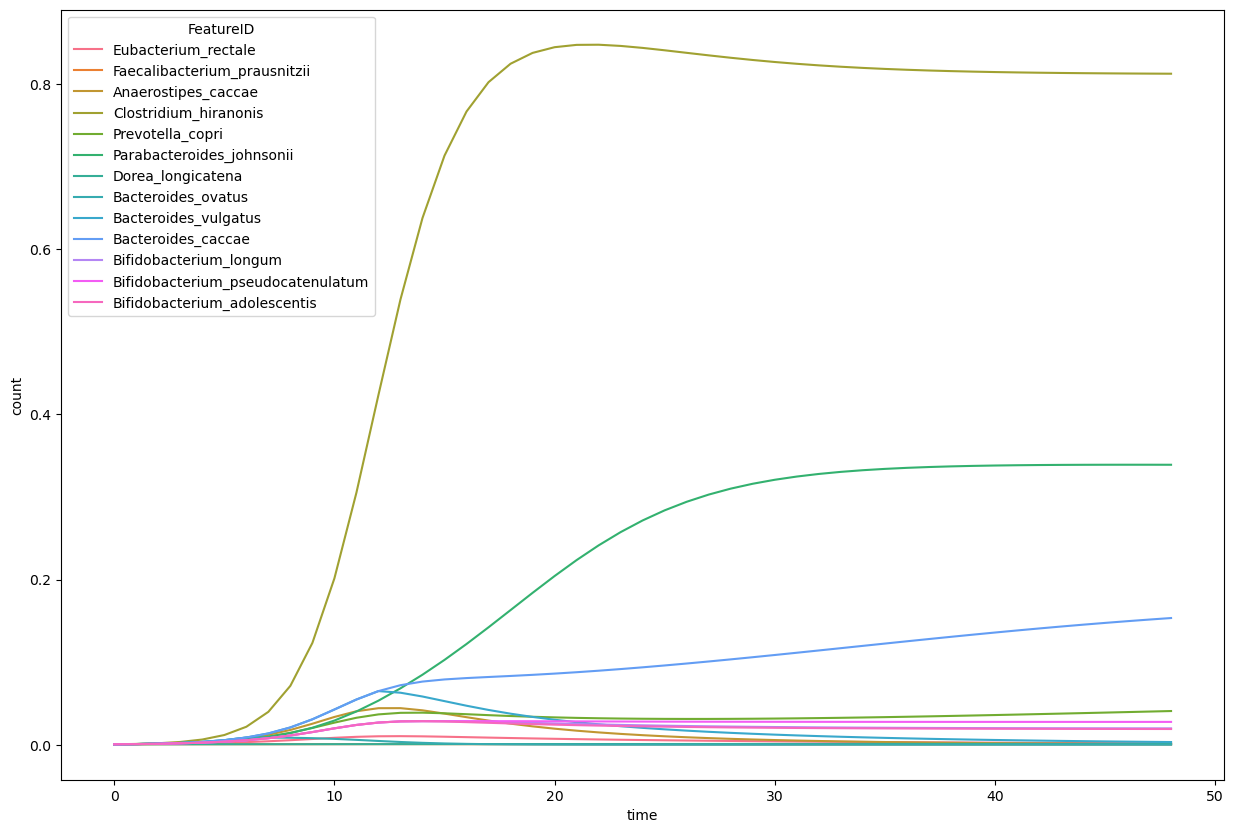

In [ ]:

FBA_biomass_df_plot = pd.DataFrame(FBA_biomass)
FBA_biomass_df_plot.index = model_abun_dict.keys()




FBA_biomass_df_plot = FBA_biomass_df_plot.melt(ignore_index=False)
FBA_biomass_df_plot = FBA_biomass_df_plot.reset_index()
FBA_biomass_df_plot.columns = ['FeatureID','time', 'count']
#FBA_biomass_df_plot['time'] = (FBA_biomass_df_plot['time']/time_scaler)-3
FBA_biomass_df_plot['count'] = FBA_biomass_df_plot['count']*10




glv_biomass_df_plot = glv_biomass_df.melt(ignore_index=False)
glv_biomass_df_plot = glv_biomass_df_plot.reset_index()
glv_biomass_df_plot.columns = ['FeatureID','time', 'count']
#FBA_biomass_df_plot['time'] = (FBA_biomass_df_plot['time']/time_scaler)-3
glv_biomass_df_plot['count'] = glv_biomass_df_plot['count']*10

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=FBA_biomass_df_plot, x='time', y='count', hue = 'FeatureID')
#plt.yscale('log')
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_abundances_over_time_test_' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [ ]:
glv_biomass_df_plot[glv_biomass_df_plot['time'] == 48]

,FeatureID,time,count
624,Eubacterium_rectale,48,1.680827e-03
625,Faecalibacterium_prausnitzii,48,1.131566e-02
626,Anaerostipes_caccae,48,8.415188e-04
627,Clostridium_hiranonis,48,8.126562e-01
628,Prevotella_copri,48,4.079484e-02
629,Parabacteroides_johnsonii,48,3.390605e-01
630,Dorea_longicatena,48,3.490921e-01
631,Bacteroides_ovatus,48,9.902108e-11
632,Bacteroides_vulgatus,48,6.281007e-04
633,Bacteroides_caccae,48,1.534308e-01


In [ ]:
m2_final_abun_bac_filt = list(m2_final_abun_bac_filt[bac_to_keep_for_inf])
m2_final_abun_bac_filt

[0.051050665359,
 0.0023186194725,
 0.49379124912,
 0.00057995871,
 0.0723651689835,
 0.1863663237614999,
 0.002537397729,
 0.2051738847135,
 0.2750105543444999,
 0.0669681755625,
 0.0073176460874999,
 0.2609632722675,
 0.0997589558639999]

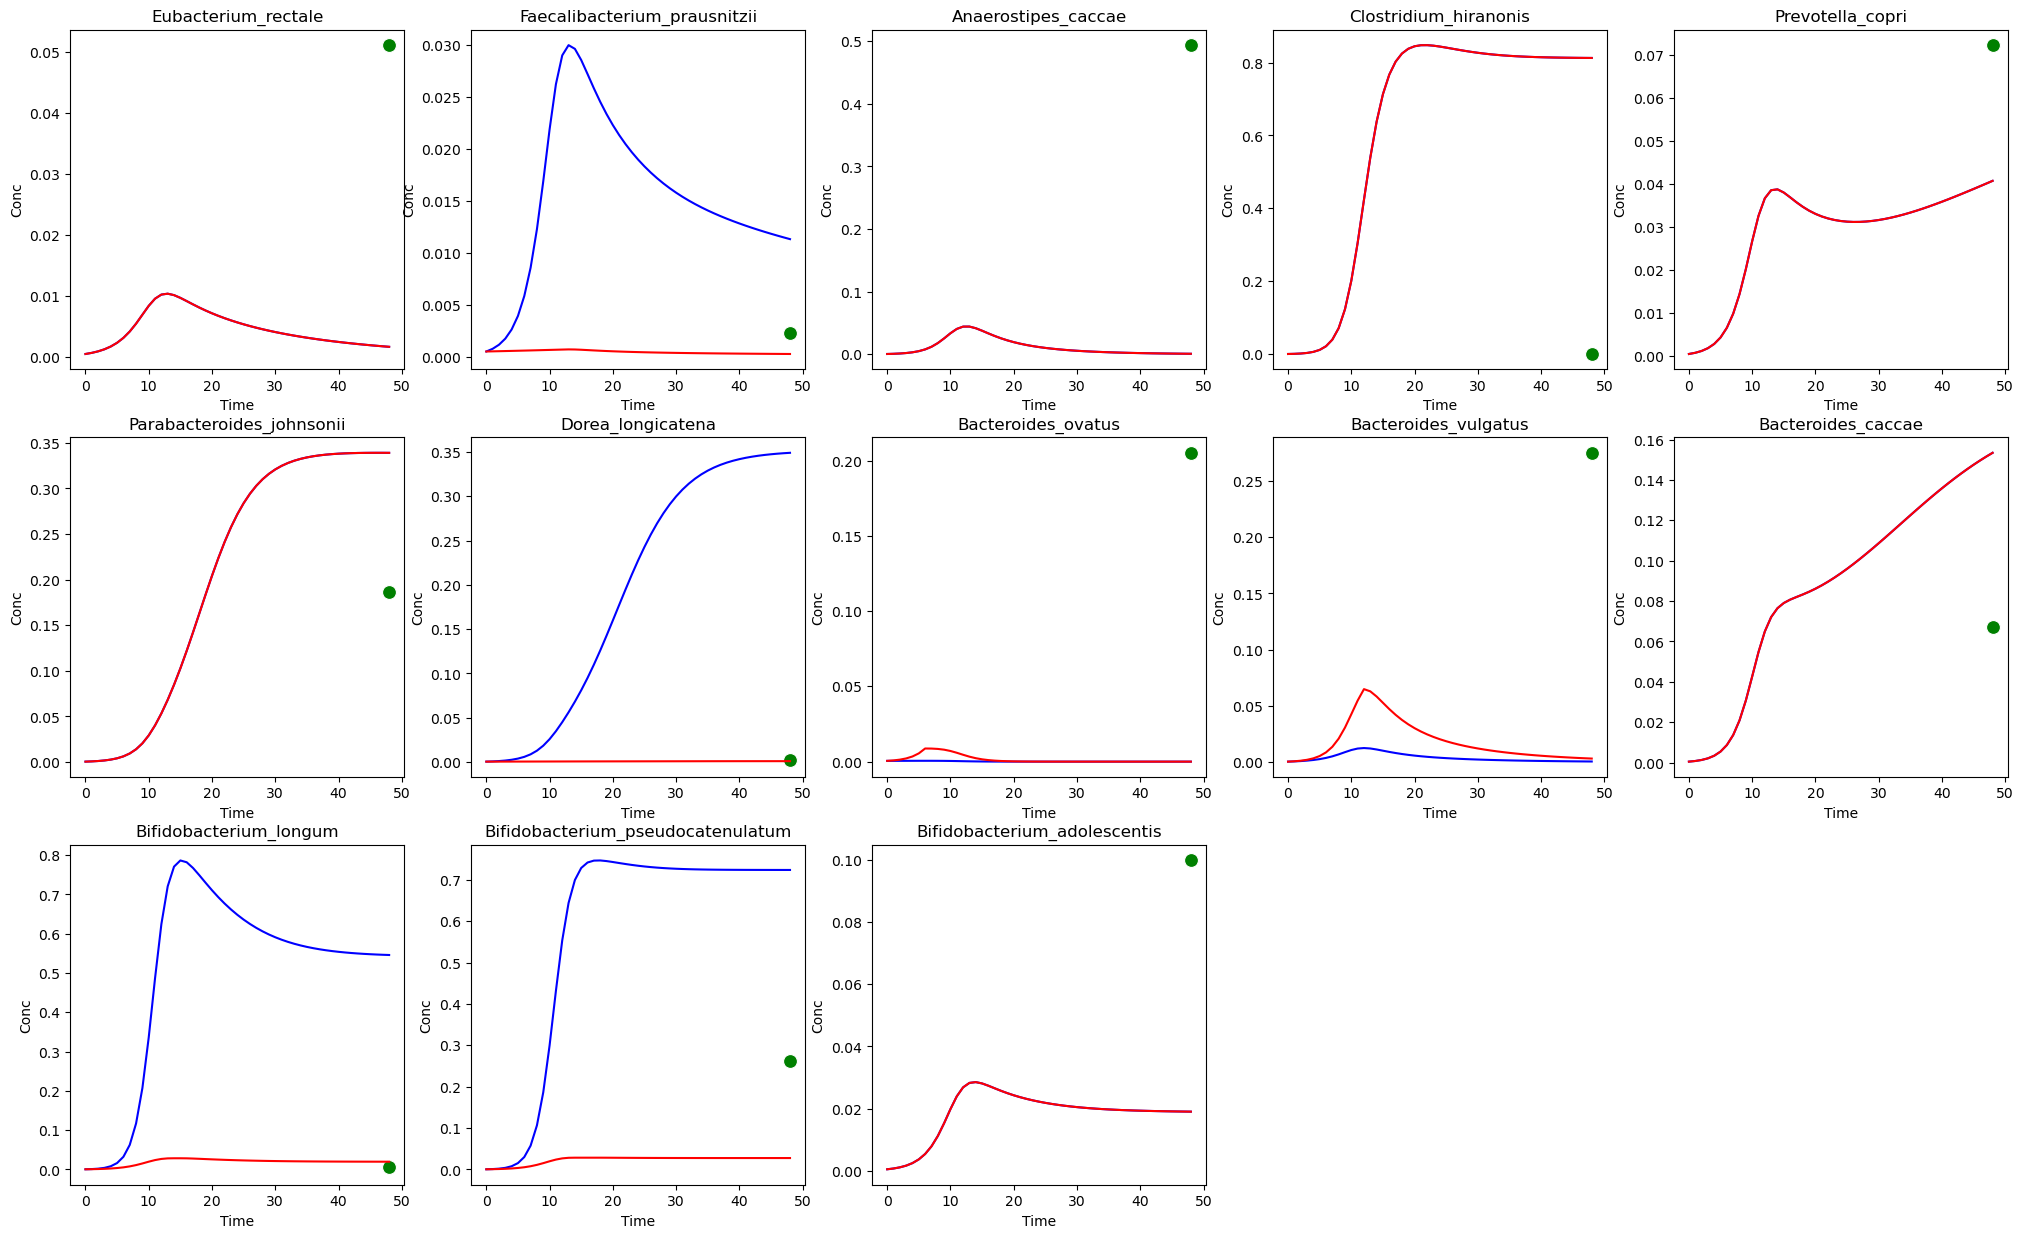

In [ ]:
num_plots = len(model_abun_dict)
cols = 5  # Number of columns in the grid
rows = (num_plots + cols - 1) // cols  # Calculate number of rows needed

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), constrained_layout=False)

# Flatten the axes array for easy iteration
axes = axes.flatten()

for i,key in enumerate(model_abun_dict):
    temp_glv = glv_biomass_df_plot[glv_biomass_df_plot['FeatureID'] == key]
    temp_FBA = FBA_biomass_df_plot[glv_biomass_df_plot['FeatureID'] == key]
        # Scatter plot on the respective subplot
    #sns.lineplot(ax=axes[i], x=temp_sim.index.to_list(), y=temp_sim.to_list(), color = 'red', lw = 2)
    sns.lineplot(ax = axes[i], data=temp_glv, x = 'time', y = 'count', color = 'blue')
    
    sns.lineplot(ax = axes[i], data=temp_FBA, x = 'time', y = 'count', color = 'red')
    sns.scatterplot(ax=axes[i], x=[48], y=m2_final_abun_bac_filt[i], color = 'green', s = 100)

    axes[i].set_title(f"{key}")
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Conc')
    #axes[i].set_yscale('log')
    #axes[i].legend_.remove()

# Hide any empty subplots if the number of plots is not a perfect square
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])


#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_mets_exp_vs_sim_individual_scatterplots_smoothed_predictions' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")

In [ ]:
FBA_biomass_df_plot

FBA_biomass_df_plot_unstack = FBA_biomass_df_plot.pivot(index='FeatureID', columns ='time')['count']
FBA_biomass_df_plot_unstack = pd.DataFrame(FBA_biomass_df_plot_unstack.sum(axis=0)).reset_index()
FBA_biomass_df_plot_unstack.columns = ['time', 'abun']
FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])
FBA_biomass_df_plot_unstack['time'] = pd.to_numeric(FBA_biomass_df_plot_unstack['time'])

# %%
### Need to plot metabolite trajectories too

met_pool_over_time_df = pd.DataFrame(met_pool_over_time)
met_pool_over_time_df = met_pool_over_time_df.fillna(0)
met_pool_over_time_df_melt= met_pool_over_time_df.melt(ignore_index=False)
met_pool_over_time_df_melt = met_pool_over_time_df_melt.reset_index()
met_pool_over_time_df_melt.columns = ['Time','Metabolite', 'Concentration']
met_pool_over_time_df_melt

# %%
met_pool_over_time_df

# %%
met_pool_over_time_df_melt[met_pool_over_time_df_melt['Concentration'] < 0]

# %%
met_pool_over_time_df_melt[met_pool_over_time_df_melt['Metabolite'] == 'EX_adn(e)']

# %
'''
total_abun_MDSINE = pd.DataFrame(bi_hourly_resolution_latent_traj.sum(axis=0)).reset_index()
total_abun_MDSINE.columns = ['time', 'abun']
total_abun_MDSINE['time'] = pd.to_numeric(total_abun_MDSINE['time'])-3
total_abun_MDSINE.head()

# %%
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=total_abun_MDSINE, x='time', y='abun')
plt.yscale('log')
plt.show()
'''

"\ntotal_abun_MDSINE = pd.DataFrame(bi_hourly_resolution_latent_traj.sum(axis=0)).reset_index()\ntotal_abun_MDSINE.columns = ['time', 'abun']\ntotal_abun_MDSINE['time'] = pd.to_numeric(total_abun_MDSINE['time'])-3\ntotal_abun_MDSINE.head()\n\n# %%\nfig, axs = plt.subplots(figsize= (15,10))\nsns.lineplot(data=total_abun_MDSINE, x='time', y='abun')\nplt.yscale('log')\nplt.show()\n"

In [ ]:
np.unique(met_pool_over_time_df_melt['Metabolite'].to_list())

array(['EX_12dgr180(e)', 'EX_13ppd(e)', 'EX_26dap_M(e)', 'EX_2ppoh(e)',
       'EX_3mop(e)', 'EX_4abut(e)', 'EX_4abz(e)', 'EX_ac(e)',
       'EX_acald(e)', 'EX_acetone(e)', 'EX_acgam(e)', 'EX_ade(e)',
       'EX_adn(e)', 'EX_ala_D(e)', 'EX_ala_L(e)', 'EX_arab_L(e)',
       'EX_arg_L(e)', 'EX_asn_L(e)', 'EX_asp_L(e)', 'EX_bglc(e)',
       'EX_btn(e)', 'EX_but(e)', 'EX_ca2(e)', 'EX_cbl1(e)', 'EX_cgly(e)',
       'EX_cl(e)', 'EX_co2(e)', 'EX_cobalt2(e)', 'EX_csn(e)', 'EX_cu2(e)',
       'EX_cys_L(e)', 'EX_cytd(e)', 'EX_dad_2(e)', 'EX_etoh(e)',
       'EX_fe2(e)', 'EX_fe3(e)', 'EX_fol(e)', 'EX_for(e)', 'EX_gcald(e)',
       'EX_glc_D(e)', 'EX_gln_L(e)', 'EX_glu_L(e)', 'EX_gly(e)',
       'EX_glyc(e)', 'EX_gsn(e)', 'EX_gua(e)', 'EX_h(e)', 'EX_h2(e)',
       'EX_h2o(e)', 'EX_h2s(e)', 'EX_hco3_L(e)', 'EX_his_L(e)',
       'EX_hxan(e)', 'EX_ile_L(e)', 'EX_indole(e)', 'EX_inost(e)',
       'EX_isobut(e)', 'EX_k(e)', 'EX_lac_L(e)', 'EX_leu_L(e)',
       'EX_lys_L(e)', 'EX_malt(e)', 'EX_meoh(e)',

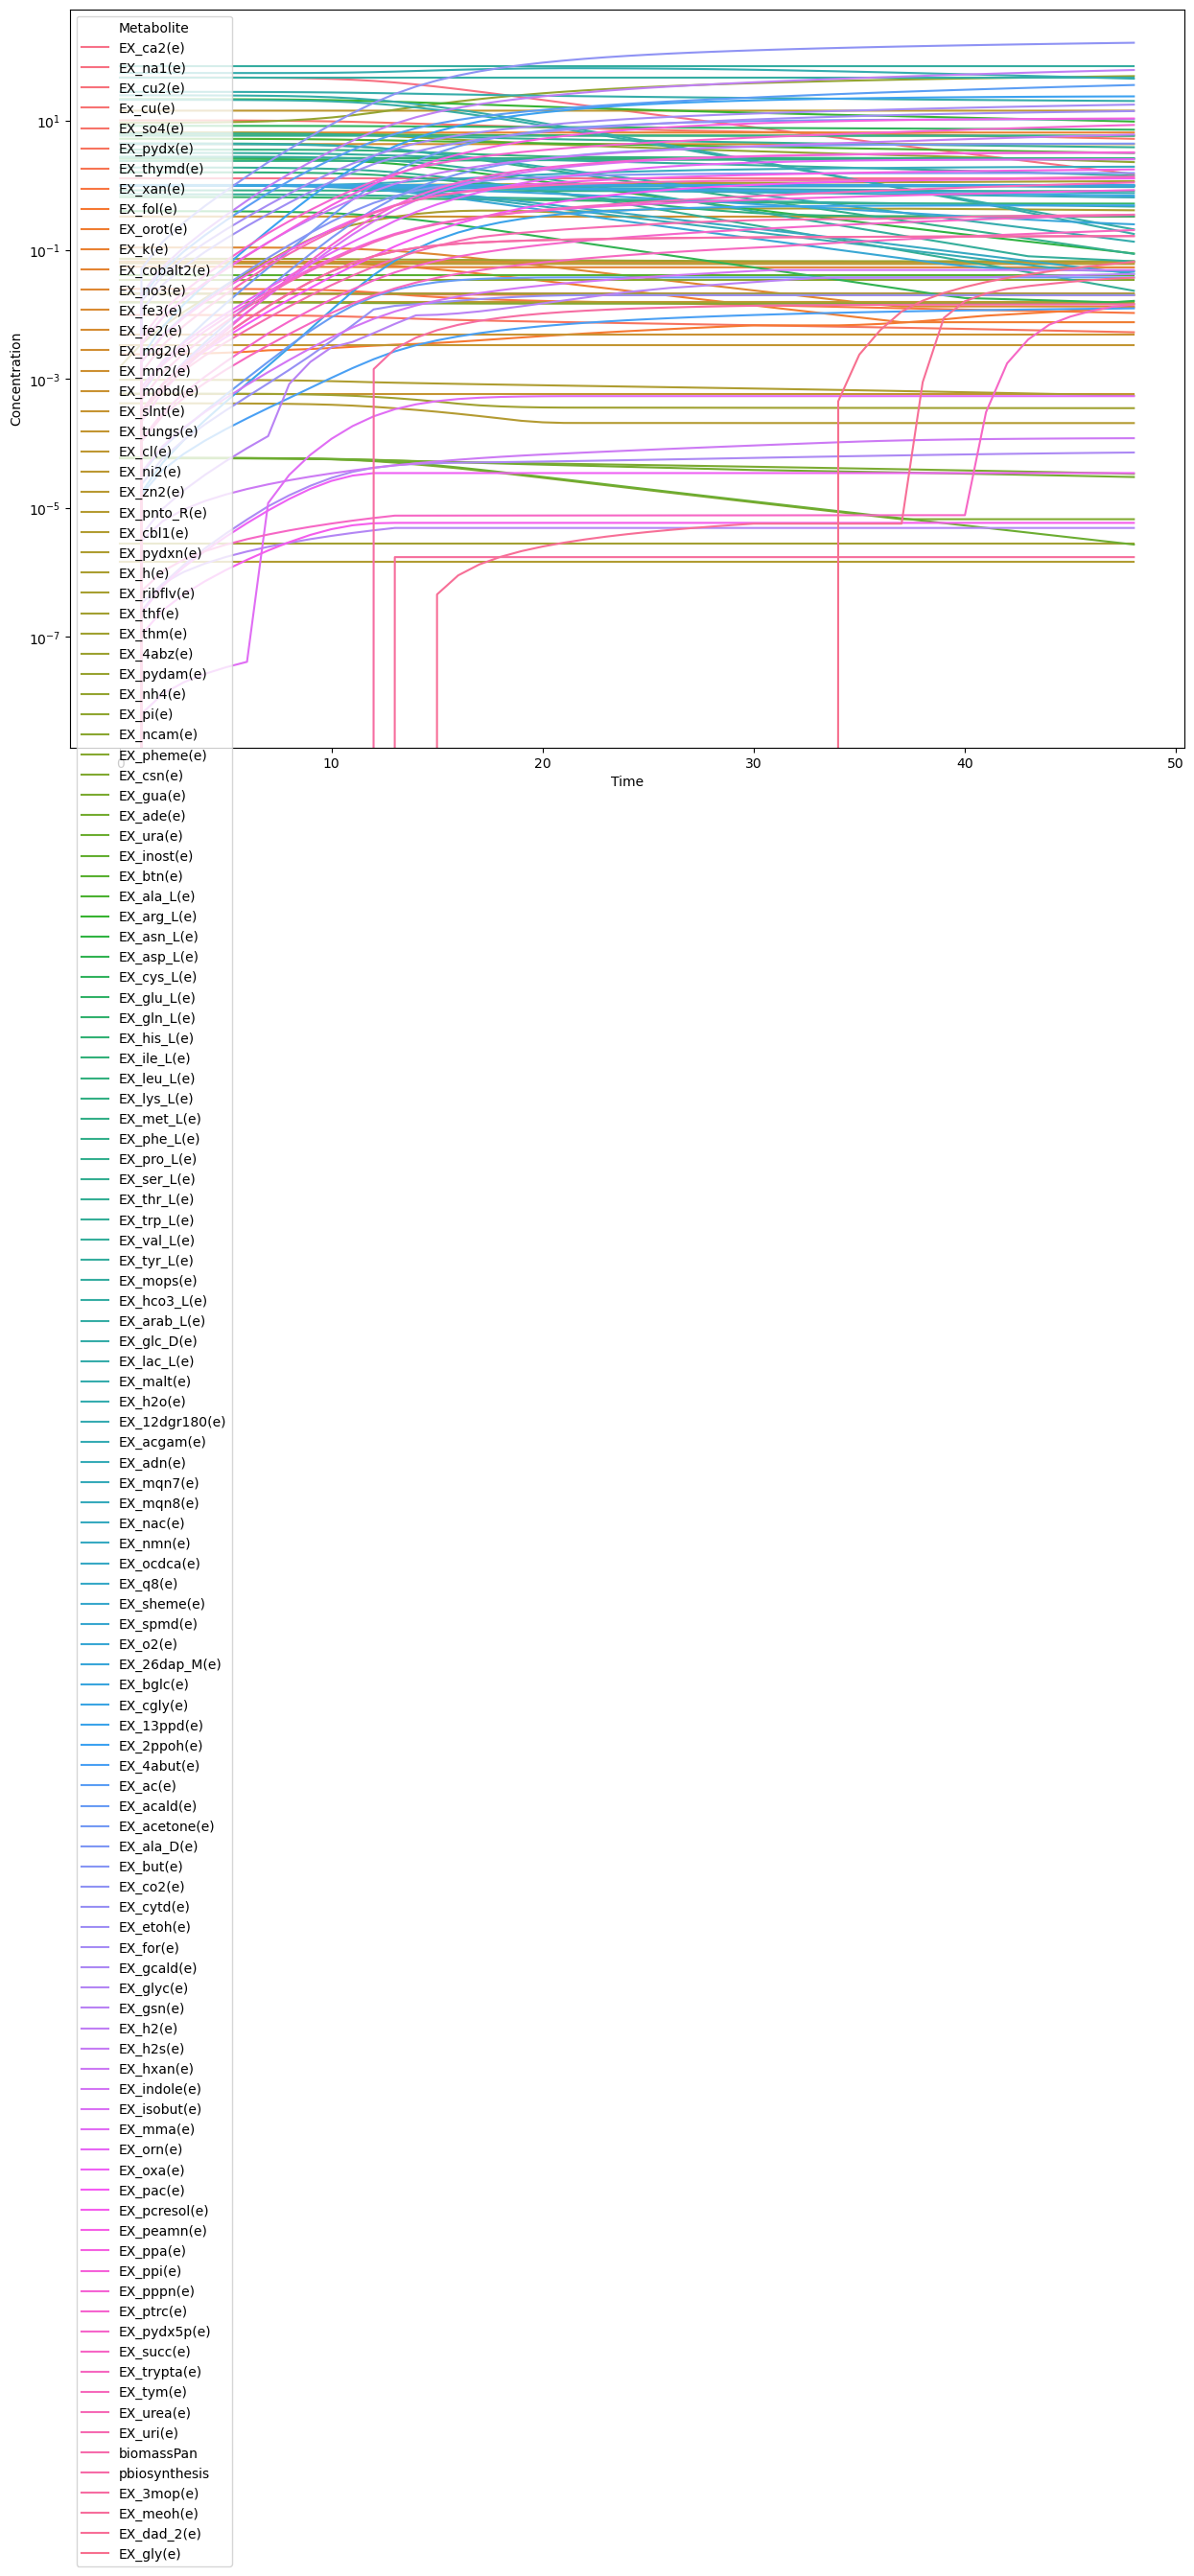

In [ ]:
plot_dir = Path(plot_dir_path)
os.makedirs(plot_dir, exist_ok=True)

fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt, x='Time', y='Concentration', hue = 'Metabolite')
plt.yscale('log')
#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")
plt.show()

In [ ]:
filt_mets = ['EX_lac_L(e)', 'EX_succ(e)','EX_but(e)', 'EX_ac(e)']

mets_present = list(set(np.unique(met_pool_over_time_df_melt['Metabolite'].to_list())).intersection(set(filt_mets)))
#filt_mets = ['EX_lac_L(e)','EX_but(e)', 'EX_ac(e)']
#filt_mets = ['EX_cpd00029_b', 'EX_cpd00159_b']

#filt_mets = ['EX_lac_L(e)']

met_pool_over_time_df_melt_filt = met_pool_over_time_df_melt.set_index('Metabolite').loc[mets_present].reset_index()


met_pool_over_time_df_melt_filt



,Metabolite,Time,Concentration
0,EX_ac(e),0,0.000000
1,EX_ac(e),1,0.018485
2,EX_ac(e),2,0.047828
3,EX_ac(e),3,0.094462
4,EX_ac(e),4,0.168574
...,...,...,...
191,EX_lac_L(e),44,20.790709
192,EX_lac_L(e),45,20.689858
193,EX_lac_L(e),46,20.592666
194,EX_lac_L(e),47,20.498758


In [ ]:
#m2_final_abun_bac_filt = list(m2_final_abun_bac_filt[bac_to_keep_for_inf])

m2_final_abun_met_filt

Butyrate     31.367751
Acetate      35.263057
Lactate      17.221521
Succinate    11.279363
Name: AC_BA_BC_BF_BH_BL_BP_BT_BY_CG_EL_ER_FP, dtype: float64

In [ ]:
met_pool_over_time_df_melt_filt[met_pool_over_time_df_melt_filt['Time'] == 48]

,Metabolite,Time,Concentration
48,EX_ac(e),48,36.106206
97,EX_succ(e),48,0.014319
146,EX_but(e),48,1.558841
195,EX_lac_L(e),48,20.407789


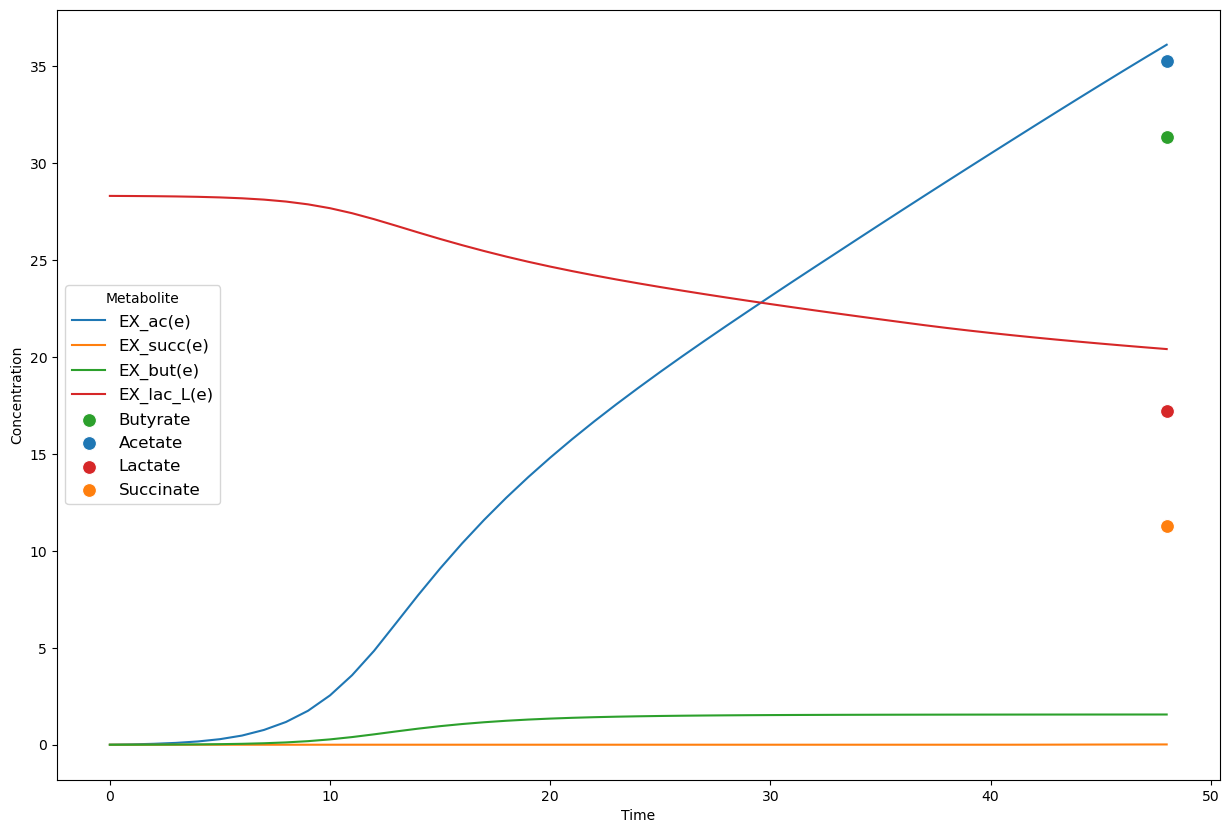

In [ ]:
# Create the base line plot
fig, ax = plt.subplots(figsize=(15, 10))
palette = sns.color_palette("tab10")  # or your preferred palette

# Let seaborn assign colors automatically by hue
sns.lineplot(
    data=met_pool_over_time_df_melt_filt,
    x='Time',
    y='Concentration',
    hue='Metabolite',
    palette=palette,
    ax=ax
)

# Extract color mapping from the lineplot legend
handles, labels = ax.get_legend_handles_labels()
color_map = dict(zip(labels, [h.get_color() for h in handles]))

# Example: map your metabolites (Butyrate, Acetate, etc.) to BiGG IDs
met_mapping = {
    "Butyrate": "EX_but(e)",
    "Acetate": "EX_ac(e)",
    "Lactate": "EX_lac_L(e)",
    "Succinate": "EX_succ(e)"
}

# Scatter for each metabolite using the same color as the corresponding line
for i, (name, bigg_id) in enumerate(met_mapping.items()):
    color = color_map[bigg_id]
    y_val = m2_final_abun_met_filt.iloc[i]
    sns.scatterplot(x=[48], y=[y_val], color=color, s=100, label=name, ax=ax)

# Adjust legend if needed
ax.legend(title="Metabolite", fontsize=12)


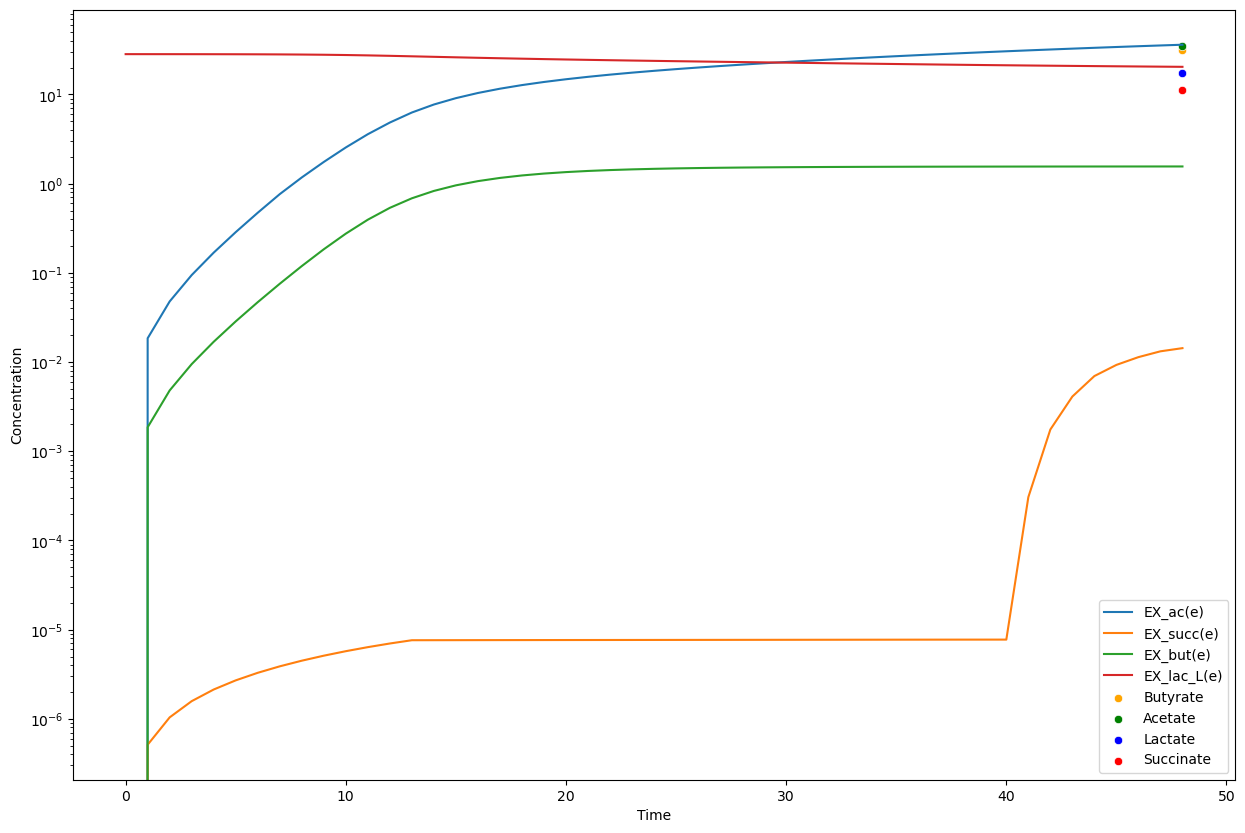

In [ ]:
fig, axs = plt.subplots(figsize= (15,10))
sns.lineplot(data=met_pool_over_time_df_melt_filt, x='Time', y='Concentration', hue = 'Metabolite')


sns.scatterplot(x = [48], y = m2_final_abun_met_filt.to_list()[0], color = 'orange', label = 'Butyrate')
sns.scatterplot(x = [48], y = m2_final_abun_met_filt.to_list()[1], color = 'green', label = 'Acetate')
sns.scatterplot(x = [48], y = m2_final_abun_met_filt.to_list()[2], color = 'blue', label = 'Lactate')
sns.scatterplot(x = [48], y = m2_final_abun_met_filt.to_list()[3], color = 'red', label = 'Succinate')

#plot_file_name = plot_dir_path + '/Subject_' + str(subject_to_plot) + '_metabolites_over_time_test_filt' + str(test_num) + '.pdf'
#plt.savefig(plot_file_name, bbox_inches="tight")
plt.yscale('log')
plt.show()


In [ ]:
met_endpoint_dict = {}
met_endpoint_dict['butyrate'] = {}
met_endpoint_dict['succinate'] = {}
met_endpoint_dict['lactate'] = {}
met_endpoint_dict['acetate'] = {}

met_endpoint_dict['butyrate']['predict'] = []
met_endpoint_dict['succinate']['predict'] = []
met_endpoint_dict['lactate']['predict'] = []
met_endpoint_dict['acetate']['predict'] = []

met_endpoint_dict['butyrate']['exp'] = []
met_endpoint_dict['succinate']['exp'] = []
met_endpoint_dict['lactate']['exp'] = []
met_endpoint_dict['acetate']['exp'] = []


met_endpoint_dict

{'butyrate': {'predict': [], 'exp': []},
 'succinate': {'predict': [], 'exp': []},
 'lactate': {'predict': [], 'exp': []},
 'acetate': {'predict': [], 'exp': []}}

In [ ]:
m2_final_abun_met_filt

Butyrate     31.367751
Acetate      35.263057
Lactate      17.221521
Succinate    11.279363
Name: AC_BA_BC_BF_BH_BL_BP_BT_BY_CG_EL_ER_FP, dtype: float64

In [ ]:
bac_abun_predict_final_df = m2_final_abun_bac.copy()
bac_abun_predict_final_df

met_abun_predict_final_df = m2_final_abun_met.copy()
met_abun_predict_final_df

,Butyrate,Acetate,Lactate,Succinate
Experiments,,,,
AC,31.478250,4.609550,19.788250,3.857050
AC_BA,46.569600,16.771500,10.611000,5.175300
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_DP_EL_ER_FP_PC_PJ_RI,16.747969,43.975915,40.116033,14.561263
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_EL_ER_FP_PC_PJ_RI,32.083082,36.775846,19.185251,17.346756
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_DP_EL_ER_FP_PC_PJ_RI,18.190000,40.175000,49.500000,7.710000
...,...,...,...,...
PC,0.000000,23.736800,19.864200,46.006000
PC_RI,15.442400,17.364100,22.486900,40.750100
PJ,0.000000,17.319400,23.916900,23.650300


In [ ]:
bac_abun_predict_final_df[:] = 0
met_abun_predict_final_df[:] = 0 

In [ ]:
bac_abun_predict_final_df.iloc[7,bac_to_keep_for_inf] = FBA_biomass_df_plot[FBA_biomass_df_plot['time'] == 48]['count'].to_list()

bac_abun_predict_final_df.head(10)

,ER_OD,FP_OD,AC_OD,CC_OD,RI_OD,DP_OD,BH_OD,CA_OD,PC_OD,DL_OD,...,BT_OD,BU_OD,BV_OD,BC_OD,BY_OD,PJ_OD,DF_OD,BL_OD,BP_OD,BA_OD
Experiments,,,,,,,,,,,,,,,,,,,,,
AC,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA_BC_BF_BH_BL_BO_BP_BY_CA_CC_CG_DL_DP_EL_PC_RI,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000
AC_BA_BC_BF_BH_BL_BP_BT_BY_CG_EL_ER_FP,0.001681,0.000267,0.000842,0.0,0.0,0.0,0.812656,0.0,0.0,0.0,...,1.548851e-09,0.0,0.0,0.003242,0.153431,0.0,0.0,0.019798,0.027648,0.019029
AC_BA_BC_BF_BH_BL_BT_BY_CC_DF_DL_DP_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000e+00,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000


In [ ]:
met_abun_predict_final_df.columns = ['EX_but(e)','EX_ac(e)', 'EX_lac_L(e)',  'EX_succ(e)']
met_abun_predict_final_df

,EX_but(e),EX_ac(e),EX_lac_L(e),EX_succ(e)
Experiments,,,,
AC,0.0,0.0,0.0,0.0
AC_BA,0.0,0.0,0.0,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.0,0.0,0.0,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_EL_ER_FP_PC_PJ_RI,0.0,0.0,0.0,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.0,0.0,0.0,0.0
...,...,...,...,...
PC,0.0,0.0,0.0,0.0
PC_RI,0.0,0.0,0.0,0.0
PJ,0.0,0.0,0.0,0.0


In [ ]:
met_pool_over_time_df_melt_filt_final_t_pt = met_pool_over_time_df_melt_filt[met_pool_over_time_df_melt_filt['Time'] == 48].set_index('Metabolite').reindex(met_abun_predict_final_df.columns)
met_pool_over_time_df_melt_filt_final_t_pt

,Time,Concentration
EX_but(e),48.0,1.558841
EX_ac(e),48.0,36.106206
EX_lac_L(e),48.0,20.407789
EX_succ(e),NaN,NaN


In [ ]:
met_abun_predict_final_df.iloc[7,:] = met_pool_over_time_df_melt_filt_final_t_pt['Concentration'].to_list()
met_abun_predict_final_df.head(10)

,EX_but(e),EX_ac(e),EX_lac_L(e),EX_succ(e)
Experiments,,,,
AC,0.000000,0.000000,0.000000,0.0
AC_BA,0.000000,0.000000,0.000000,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BT_BU_BV_BY_CA_CC_CG_CH_DF_DL_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_DP_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BU_BV_BY_CA_CC_CG_DF_DL_EL_ER_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0
AC_BA_BC_BF_BH_BL_BO_BP_BY_CA_CC_CG_DL_DP_EL_PC_RI,0.000000,0.000000,0.000000,0.0
AC_BA_BC_BF_BH_BL_BP_BT_BY_CG_EL_ER_FP,1.558841,36.106206,20.407789,NaN
AC_BA_BC_BF_BH_BL_BT_BY_CC_DF_DL_DP_FP_PC_PJ_RI,0.000000,0.000000,0.000000,0.0


In [ ]:
m2_init_abun.index.to_list()[sim_to_grab]

'AC_BA_BC_BF_BH_BL_BP_BT_BY_CG_EL_ER_FP'